# EDA выборки магазинов

## Цель ноутбука

В ноутбуке `01_data_research` из 1115 магазинов Rossmann была собрана выборка из 40 магазинов. Здесь эта выборка рассматривается как самостоятельный датасет: все проверки и выводы делаются только на ней.

Задача ноутбука - разобрать данные так, чтобы каждое решение о признаках и модели было обосновано: динамика по времени, недельная и годовая сезонность, распределение целевой переменной, выбросы, пропуски и праздники.

Магазины служат аналогом ресторанов: число покупателей за день (`Customers`) - аналог числа гостей и целевая переменная, выручка (`Sales`) - аналог выручки ресторана, их отношение - средний чек. Сам анализ ведется в терминах магазинов, аналогия с ресторанами используется только в объяснениях.

## Правила анализа

- **Только тренировочный период** (до 19.06.2015 включительно). Отложенный период (последние 6 недель) не используется, чтобы ни одно решение о признаках не было принято с оглядкой на данные, на которых потом оценивается модель.
- **Пропуски и закрытия разбираются до любой статистики по покупателям**: иначе статистика смешивает реальный спрос, закрытия и сбои выгрузки.

## Как сравниваем магазины разного масштаба

Число покупателей у магазинов выборки различается в несколько раз, поэтому для разных задач используются разные шкалы:
- **сырые значения** (покупателей в день) - когда важна интерпретация в исходных единицах или сам масштаб (примеры отдельных магазинов, связь уровня и амплитуды колебаний);
- **индекс** - число покупателей, деленное на медиану магазина в открытые дни трейна: 1.0 - обычный день, 1.3 - на 30% больше обычного. Индекс позволяет усреднять и сравнивать магазины разного масштаба;
- **логарифм** числа покупателей - когда нужно превратить относительные (мультипликативные) эффекты в аддитивные.

Шкала каждого графика подписана на его оси.

## 0. Загрузка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import seaborn as sns
from scipy.stats import norm
from statsmodels.tsa.seasonal import STL

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

# код проекта - пакет src/customers_prediction; параметры выбраны в ноутбуке 01_data_research:
# TEST_START - первый день отложенного периода (раздел 2), N_LONG - порог длинного закрытия, дней (раздел 4)
from customers_prediction.config import N_LONG, PROCESSED_DIR, TEST_START, TRAIN_END
from customers_prediction.data import DAY_STATUSES, load_history, restore_calendar

SEGMENT_COLORS = {"mid": "#2a78d6", "high_check": "#eb6834", "high_traffic": "#1baf7a"}

In [2]:
train_subset = load_history()
store_subset = pd.read_csv(PROCESSED_DIR / "store_subset.csv")
selected = pd.read_csv(PROCESSED_DIR / "selected_stores.csv", index_col="Store")

train_part = train_subset[train_subset["Date"] <= TRAIN_END]

print(f"Магазинов: {train_part['Store'].nunique()}")
print(f"Период трейна: {train_part['Date'].min().date()} - {train_part['Date'].max().date()}")
print(f"Строк в трейне: {len(train_part)} (всего в выборке вместе с отложенным периодом: {len(train_subset)})")
selected["segment"].value_counts().rename("магазинов").to_frame()

Магазинов: 40
Период трейна: 2013-01-01 - 2015-06-19
Строк в трейне: 34344 (всего в выборке вместе с отложенным периодом: 36024)


,магазинов
segment,
mid,24
high_check,11
high_traffic,5


## 1. Пропуски и статусы дней

### 1.1 Восстановление календаря

Строим полную сетку "магазин x дата" и присваиваем каждому дню статус:
- `open` - магазин открыт, число покупателей - реальный спрос;
- `closed` - регулярное закрытие: серия закрытых дней короче `N_LONG` (воскресенье, праздник), покупателей 0;
- `absent` - точки нет в этот период: серия закрытых дней от `N_LONG` (ремонт или магазин появился в данных позже);
- `missing_export` - строки нет в выгрузке, значение неизвестно;
- `anomaly` - магазин отмечен открытым, но покупателей 0.

Исходные `Customers` и `Sales` не меняются, очищенные значения записываются в отдельные колонки `customers_clean` и `sales_clean`. Граница календаря передается параметром: в анализе это конец трейна, а при прогнозе - дата прогноза, так что обучение и прогноз используют один и тот же код подготовки.

In [3]:
# restore_calendar - функция пакета (src/customers_prediction/data.py):
# тот же код подготовки данных используют обучение модели и прогноз
help(restore_calendar)

Help on function restore_calendar in module customers_prediction.data:

restore_calendar(df: pandas.DataFrame, end: pandas.Timestamp, n_long: int = 3) -> pandas.DataFrame
    Восстанавливает полный календарь "магазин x дата" до даты end включительно
    и присваивает каждому дню статус.
    
    Статусы:
    - open - магазин открыт, число покупателей - реальный спрос;
    - closed - регулярное закрытие: серия Open = 0 короче n_long дней (воскресенье, праздник), покупателей 0;
    - absent - точки нет в этот период: серия Open = 0 от n_long дней (ремонт или магазин появился позже);
    - missing_export - строки нет в выгрузке, значение неизвестно;
    - anomaly - магазин отмечен открытым, но покупателей 0.
    
    Исходные Customers и Sales не меняются, очищенные значения - в customers_clean и sales_clean.



In [4]:
calendar = restore_calendar(train_part, end=TRAIN_END)

assert not calendar.duplicated(["Store", "Date"]).any(), "дубликаты магазин x дата"
assert len(calendar) == calendar["Store"].nunique() * calendar["Date"].nunique(), "календарь неполный"
assert calendar.loc[calendar["day_status"] == "closed", "customers_clean"].eq(0).all()
assert calendar.loc[calendar["day_status"].isin(["absent", "missing_export", "anomaly"]),
                    "customers_clean"].isna().all()

print(f"Строк в календаре: {len(calendar)} (было в данных: {len(train_part)})")
print(f"Дней с покупателями > 0 и выручкой 0: "
      f"{(calendar['Customers'].gt(0).fillna(False) & calendar['Sales'].eq(0).fillna(False)).sum()}")

status_counts = calendar["day_status"].value_counts().reindex(DAY_STATUSES).rename("дней").to_frame()
status_counts["доля"] = (status_counts["дней"] / len(calendar)).round(4)
status_counts["магазинов"] = calendar.groupby("day_status", observed=False)["Store"].nunique()
status_counts

Строк в календаре: 36000 (было в данных: 34344)
Дней с покупателями > 0 и выручкой 0: 0


,дней,доля,магазинов
day_status,,,
open,28674,0.7965,40
closed,5162,0.1434,35
absent,503,0.0140,9
missing_export,1656,0.0460,9
anomaly,5,0.0001,5


Календарь восстановлен: 40 магазинов x 900 дней = 36 000 строк вместо 34 344 в данных. Восстановлено 1 656 дней - ровно 9 магазинов x 184 дня пробела выгрузки второго полугодия 2014 года.

Около 80% дней - обычные открытые дни, 14% - регулярные закрытия (воскресенья и праздники), 1.4% - периоды, когда точки нет (503 дня у 9 магазинов), и 5 аномальных дней у 5 магазинов. Регулярные закрытия есть у 35 магазинов из 40, у оставшихся 5 их нет совсем. Дней, когда покупатели есть, а выручка нулевая, в выборке нет, поэтому очищенная выручка следует тем же правилам, что и очищенное число покупателей.

**Для модели:** дни, отсутствующие в выгрузке, периоды без точки и аномалии не несут информации о спросе, и подставлять в них нули нельзя - иначе модель выучит ложные провалы.

### 1.2 Карта статусов

Каждая строка - магазин (сгруппированы по сегментам), каждый столбец - день. Аномальные дни занимают по одному пикселю, поэтому дополнительно отмечены крестиками.

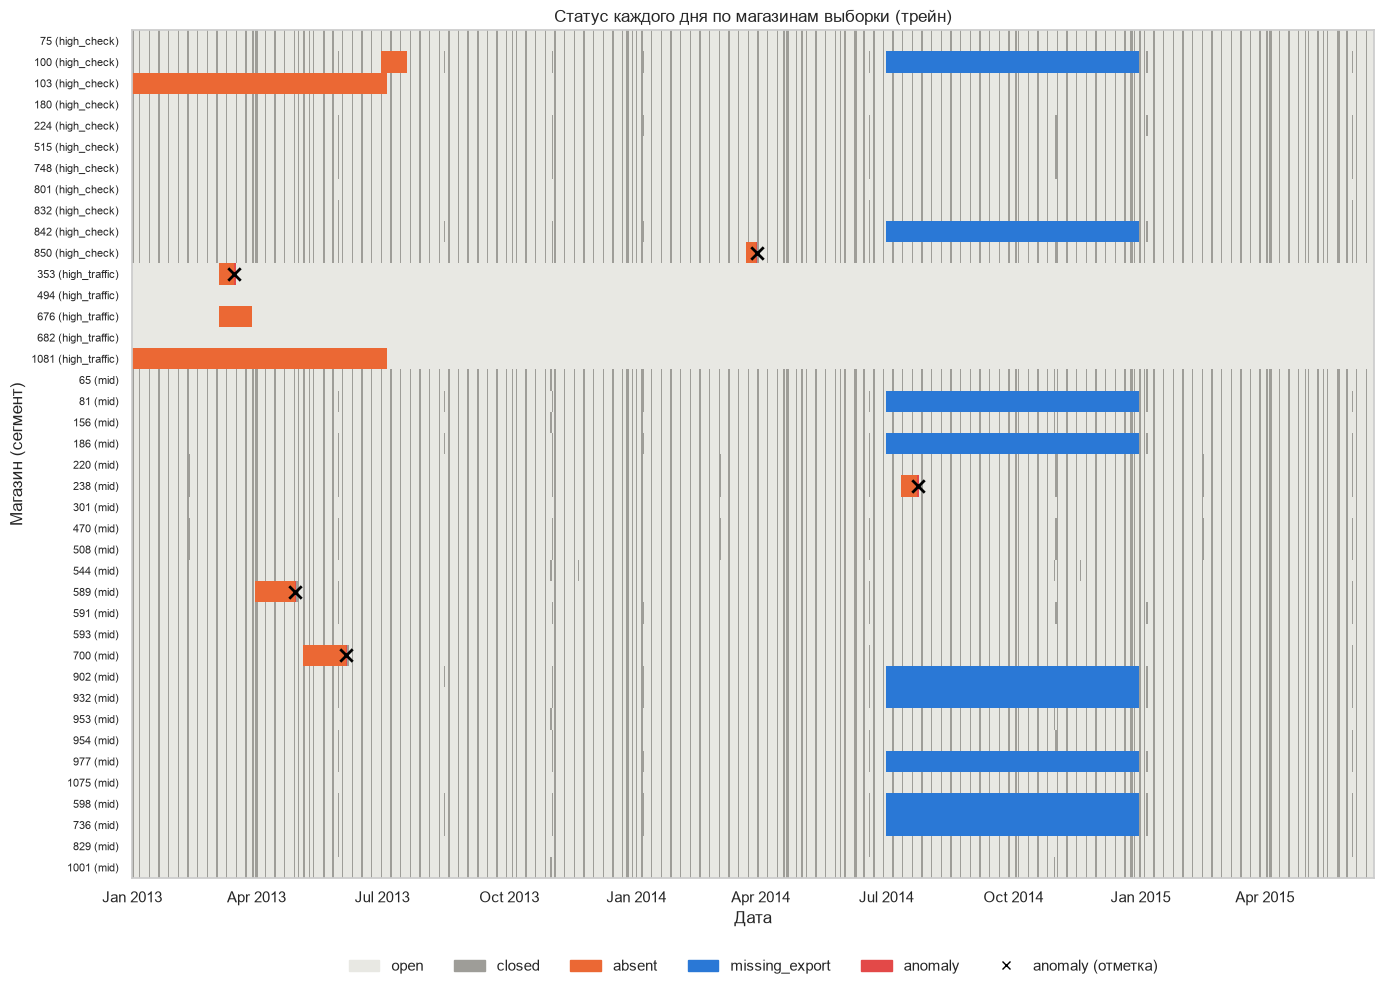

In [5]:
STATUS_COLORS = {"open": "#e8e8e3", "closed": "#9e9d98", "absent": "#eb6834",
                 "missing_export": "#2a78d6", "anomaly": "#e34948"}

store_order = (selected.loc[calendar["Store"].unique()]
               .sort_values(["segment", "StoreType"]).index.tolist())
status_map = (calendar.assign(code=calendar["day_status"].cat.codes)
              .pivot(index="Store", columns="Date", values="code")
              .loc[store_order])

fig, ax = plt.subplots(figsize=(14, 10))
x_start, x_end = mdates.date2num(status_map.columns[0]), mdates.date2num(status_map.columns[-1])
ax.imshow(status_map.to_numpy(), aspect="auto", interpolation="nearest",
          cmap=ListedColormap([STATUS_COLORS[s] for s in DAY_STATUSES]), vmin=0, vmax=len(DAY_STATUSES) - 1,
          extent=[x_start, x_end, len(store_order) - 0.5, -0.5])

anomaly_days = calendar[calendar["day_status"] == "anomaly"]
ax.scatter(mdates.date2num(anomaly_days["Date"]), [store_order.index(s) for s in anomaly_days["Store"]],
           marker="x", s=80, color="black", linewidth=2, zorder=3)

ax.set_yticks(range(len(store_order)),
              [f"{s} ({selected.loc[s, 'segment']})" for s in store_order], fontsize=8)
ax.xaxis_date()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set(title="Статус каждого дня по магазинам выборки (трейн)", xlabel="Дата", ylabel="Магазин (сегмент)")
ax.grid(False)
ax.legend(handles=[Patch(color=STATUS_COLORS[s], label=s) for s in DAY_STATUSES]
          + [plt.Line2D([], [], marker="x", color="black", linestyle="", label="anomaly (отметка)")],
          loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=6, frameon=False)
plt.tight_layout()
plt.show()

Карта показывает все три вида пропусков, и они заметно различаются по форме:
- **регулярные закрытия** (серые полосы) - короткие и синхронные у многих магазинов: воскресенья и праздники. У всех 5 магазинов `high_traffic` таких полос нет - они работают без выходных, включая праздники;
- **пробел в выгрузке** (синий) - один сплошной блок с июля по декабрь 2014 года одновременно у 9 магазинов: это сбой выгрузки, а не поведение магазинов;
- **периоды, когда точки нет** (оранжевый) - индивидуальные и разной длины, в основном в первой половине 2013 года. У магазинов 103 и 1081 это первые полгода данных: магазины появились позже;
- **аномальные дни** (крестики) стоят на правом краю оранжевых периодов, то есть сразу после окончания длинного закрытия. Пока это гипотеза - ее проверка следует ниже.

**Для модели:** пропуски не случайны во времени. У 9 магазинов нет второго полугодия 2014 года, поэтому их осенняя и рождественская сезонность 2014 года неизвестна, а лаг "тот же день год назад" для июля - декабря 2015 года у них будет пустым. Это касается и большей части отложенного периода (июль 2015 года), поэтому лаг год к году не может быть основным признаком.

### 1.3 Где находятся аномальные дни

Гипотеза из ноутбука 01: день "открыт, но 0 покупателей" - это граница закрытия (магазин формально открыт, но еще или уже не работает). Для каждого аномального дня ищем ближайшее закрытие до и после него.

Соседство с обычным закрытым днем само по себе мало о чем говорит: почти любой понедельник или суббота соседствует с закрытым воскресеньем. Поэтому отдельно смотрим на расстояние до **длинного** закрытия (`absent`) и сравниваем долю аномальных дней рядом с закрытием с той же долей для обычных открытых дней.

In [6]:
def nearest_closure(days: pd.DataFrame, closures: pd.DataFrame, direction: str) -> pd.DataFrame:
    '''Для каждого дня из days находит ближайший день закрытия того же магазина до (backward) или после (forward).'''
    suffix = "before" if direction == "backward" else "after"
    return pd.merge_asof(
        days.sort_values("Date"),
        closures.sort_values("Date").rename(columns={"Date": f"closure_{suffix}",
                                                     "day_status": f"status_{suffix}"}),
        left_on="Date", right_on=f"closure_{suffix}", by="Store", direction=direction,
    )


closures = calendar.loc[calendar["day_status"].isin(["closed", "absent"]), ["Store", "Date", "day_status"]]
anomalies = calendar.loc[calendar["day_status"] == "anomaly", ["Store", "Date"]]

anomaly_context = (nearest_closure(anomalies, closures, "backward")
                   .merge(nearest_closure(anomalies, closures, "forward"), on=["Store", "Date"])
                   .assign(days_after_closure=lambda d: (d["Date"] - d["closure_before"]).dt.days,
                           days_before_closure=lambda d: (d["closure_after"] - d["Date"]).dt.days,
                           weekday=lambda d: d["Date"].dt.day_name()))

long_closures = closures[closures["day_status"] == "absent"].drop(columns="day_status")
anomaly_context = (anomaly_context
                   .merge(nearest_closure(anomalies, long_closures.assign(day_status="absent"), "backward")
                          [["Store", "Date", "closure_before"]].rename(columns={"closure_before": "absent_before"}),
                          on=["Store", "Date"])
                   .merge(nearest_closure(anomalies, long_closures.assign(day_status="absent"), "forward")
                          [["Store", "Date", "closure_after"]].rename(columns={"closure_after": "absent_after"}),
                          on=["Store", "Date"])
                   .assign(days_after_absent=lambda d: (d["Date"] - d["absent_before"]).dt.days,
                           days_before_absent=lambda d: (d["absent_after"] - d["Date"]).dt.days))

display(anomaly_context[["Store", "Date", "weekday", "status_before", "days_after_closure",
                         "status_after", "days_before_closure", "days_after_absent", "days_before_absent"]])

# Та же доля "вплотную к закрытию" для обычных открытых дней - как точка отсчета
open_days = calendar.loc[calendar["day_status"] == "open", ["Store", "Date"]]
open_context = (nearest_closure(open_days, closures, "backward")
                .merge(nearest_closure(open_days, closures, "forward"), on=["Store", "Date"]))
open_adjacent = ((open_context["Date"] - open_context["closure_before"]).dt.days.eq(1)
                 | (open_context["closure_after"] - open_context["Date"]).dt.days.eq(1))
anomaly_adjacent = anomaly_context["days_after_closure"].eq(1) | anomaly_context["days_before_closure"].eq(1)
print(f"Вплотную к закрытому дню: аномальных дней {anomaly_adjacent.mean():.0%} "
      f"({anomaly_adjacent.sum()} из {len(anomaly_context)}), обычных открытых дней {open_adjacent.mean():.0%}")

,Store,Date,weekday,status_before,days_after_closure,status_after,days_before_closure,days_after_absent,days_before_absent
0,353,2013-03-16,Saturday,absent,1,NaN,NaN,1,NaN
1,589,2013-04-29,Monday,absent,1,closed,1.0,1,NaN
2,700,2013-06-05,Wednesday,absent,1,closed,1.0,1,NaN
3,850,2014-03-29,Saturday,absent,1,closed,1.0,1,NaN
4,238,2014-07-24,Thursday,absent,1,closed,3.0,1,NaN


Вплотную к закрытому дню: аномальных дней 100% (5 из 5), обычных открытых дней 33%


**Гипотеза подтвердилась.** Все 5 аномальных дней стоят ровно на следующий день после окончания длинного закрытия (`days_after_absent` = 1): магазин формально уже открыт, но покупателей еще нет. Для сравнения, вплотную к закрытому дню стоят лишь 33% обычных открытых дней (в основном понедельники и субботы рядом с закрытым воскресеньем), а у аномальных дней - 100%, причем именно к длинному закрытию.

Ограничение: в выборке всего 5 таких дней, поэтому вывод опирается на небольшое число случаев, но закономерность выполняется без исключений.

**Для модели:** аномальный день - это последний день закрытия, а не нулевой спрос. Он получает пропуск (NaN) вместо 0 и не участвует ни в обучении, ни в лагах. Отдельный статус `anomaly` оставляем: обработка у него та же, что у `absent`, но статус сохраняет информацию о качестве данных.

### 1.4 Что происходит после возвращения точки

Если в первые дни после длинного закрытия поток заметно отличается от обычного, лаги и скользящие средние в этот период будут ошибаться, и понадобится признак "дней с момента открытия". Считаем индекс покупателей (к медиане магазина) в первые 8 недель после каждого длинного закрытия. Магазин, закрытый до конца трейна, в расчет не попадает.

Возвращений после длинного закрытия: 9 (магазинов: 9)


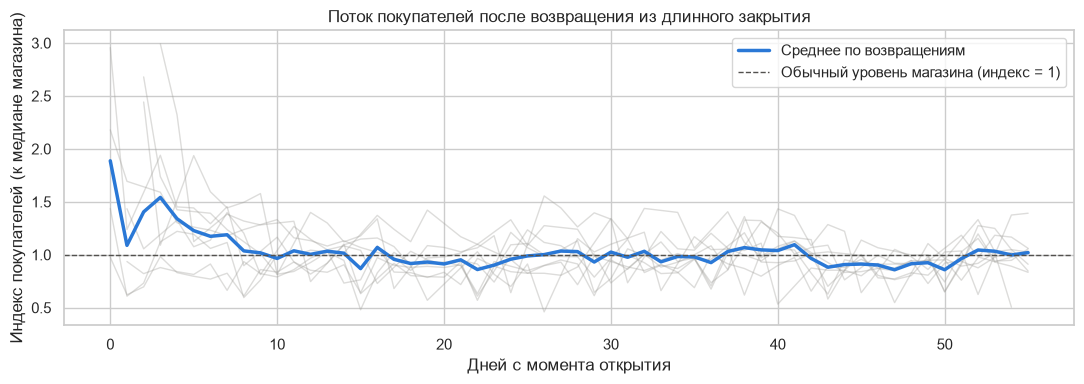

,mean,median,size
week,,,
1.0,1.347,1.232,49
2.0,1.044,1.016,56
3.0,0.952,0.939,56
4.0,0.958,0.942,54
5.0,0.988,0.981,55
6.0,1.026,1.041,57
7.0,0.906,0.911,57
8.0,0.977,0.966,57


In [7]:
store_median = (calendar[calendar["day_status"] == "open"]
                .groupby("Store")["customers_clean"].median().rename("store_median"))
calendar = calendar.join(store_median, on="Store")
calendar["index"] = calendar["customers_clean"] / calendar["store_median"]

is_absent = calendar["day_status"].eq("absent")
is_reopen = ~is_absent & is_absent.groupby(calendar["Store"]).shift(fill_value=False)
calendar["reopen_date"] = calendar["Date"].where(is_reopen).groupby(calendar["Store"]).ffill()
calendar["days_since_reopen"] = (calendar["Date"] - calendar["reopen_date"]).dt.days

REOPEN_WINDOW = 56
after_reopen = calendar[calendar["days_since_reopen"].between(0, REOPEN_WINDOW - 1)
                        & calendar["day_status"].eq("open")]
reopen_profile = (after_reopen.assign(week=after_reopen["days_since_reopen"] // 7 + 1)
                  .groupby("week")["index"].agg(["mean", "median", "size"]))
print(f"Возвращений после длинного закрытия: {int(is_reopen.sum())} (магазинов: {calendar.loc[is_reopen, 'Store'].nunique()})")

fig, ax = plt.subplots(figsize=(11, 4))
for (store, reopen), part in after_reopen.groupby(["Store", "reopen_date"]):
    ax.plot(part["days_since_reopen"], part["index"], color="#9e9d98", alpha=0.35, linewidth=1)
daily_mean = after_reopen.groupby("days_since_reopen")["index"].mean()
ax.plot(daily_mean.index, daily_mean, color="#2a78d6", linewidth=2.5, label="Среднее по возвращениям")
ax.axhline(1, color="#52514e", linestyle="--", linewidth=1, label="Обычный уровень магазина (индекс = 1)")
ax.set(title="Поток покупателей после возвращения из длинного закрытия",
       xlabel="Дней с момента открытия", ylabel="Индекс покупателей (к медиане магазина)")
ax.legend()
plt.tight_layout()
plt.show()

reopen_profile.round(3)

После длинного закрытия поток заметно выше обычного: в первую неделю индекс в среднем 1.35 (медиана 1.23), а в отдельные дни у отдельных магазинов - в 2-3 раза выше обычного уровня. Уже со второй недели поток возвращается к норме (1.04), а в следующие недели колеблется около 1 (от 0.91 до 1.03). Оценка построена на 9 возвращениях у 9 магазинов.

**Для модели:** первая неделя после открытия - особый период. Лаги в эти дни смотрят либо на закрытие (пропуск), либо на период до закрытия, и всплеск не предсказывают. Кандидат в признаки - "дней с момента открытия после длинного закрытия" или флаг первой недели после открытия. Сам всплеск - реальное событие (открытие после ремонта), а не выброс, и удалять его нельзя.

### 1.5 Как обрабатываем каждый статус

- `open` - реальный спрос. Участвует в обучении, в метриках и в расчете лагов и скользящих статистик.
- `closed` - регулярное закрытие, покупателей по факту 0. Расписание известно заранее, поэтому такой день моделью не прогнозируется: прогноз для него - 0 по правилу, а в метриках он не участвует (иначе MAPE не определена, а модель училась бы угадывать расписание). Значение закрытого дня нельзя использовать в лагах как обычный спрос; как именно считать лаги через закрытые дни, будет решаться на этапе признаков.
- `absent` - точки нет. Не участвует ни в обучении, ни в метриках, лаги и скользящие статистики через такой период не протягиваются. Первая неделя после возвращения - особый период (раздел 1.4).
- `missing_export` - значение неизвестно. Обрабатывается так же, как `absent`: не участвует в обучении и метриках, в лагах - пропуск, а не 0.
- `anomaly` - по разделу 1.3 это день открытия после длинного закрытия, фактически еще часть закрытия. Обрабатывается так же, как `absent`.

Главный принцип: 0 ставится только туда, где магазин действительно был закрыт по расписанию. Во всех остальных случаях спрос неизвестен, и значение - пропуск (NaN).

## 2. Распределение целевой переменной

### 2.1 Распределение покупателей в открытые дни

Смотрим распределение в трех шкалах: сырые значения показывают смешение магазинов разного масштаба, индекс - форму распределения после выравнивания масштаба, логарифм - насколько распределение становится симметричным.

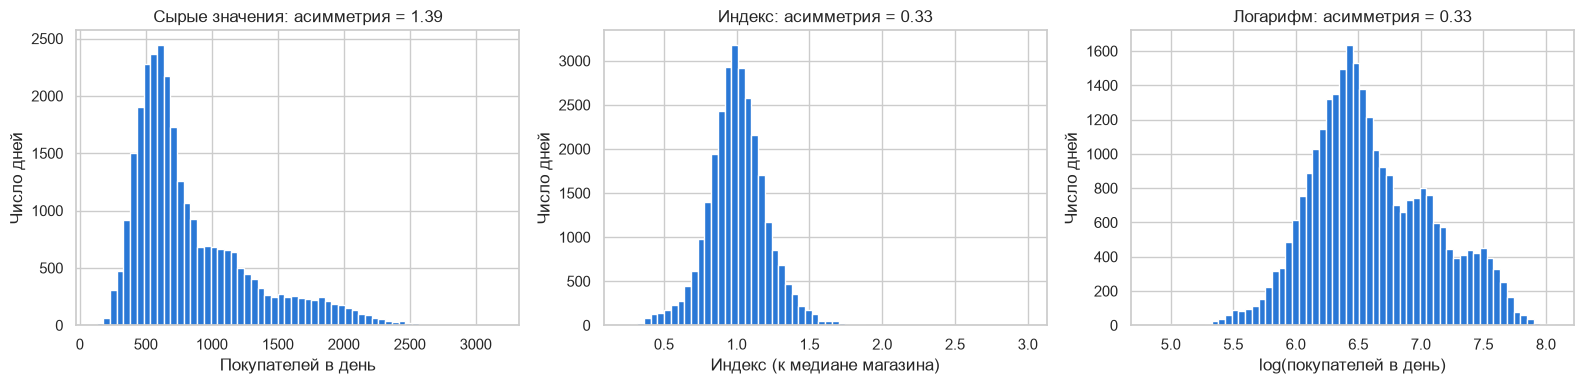

In [8]:
open_calendar = calendar[calendar["day_status"] == "open"].join(selected["segment"], on="Store")
customers_open = open_calendar["customers_clean"].astype(float)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
scales = [
    (customers_open, "Покупателей в день", "Сырые значения"),
    (open_calendar["index"].astype(float), "Индекс (к медиане магазина)", "Индекс"),
    (np.log(customers_open), "log(покупателей в день)", "Логарифм"),
]
for ax, (values, xlabel, title) in zip(axes, scales):
    ax.hist(values, bins=60, color="#2a78d6", edgecolor="white")
    ax.set(title=f"{title}: асимметрия = {values.skew():.2f}", xlabel=xlabel, ylabel="Число дней")
plt.tight_layout()
plt.show()

В исходных значениях распределение числа покупателей сильно скошено вправо (асимметрия 1,39). Основная масса наблюдений приходится на 400-800 покупателей, но присутствует длинный хвост до 3000 покупателей. Дополнительные скопления в областях 1000-1200 и 1700-2000 покупателей связаны с магазинами большего масштаба.

Нормализация относительно медианного уровня конкретного магазина делает распределение значительно компактнее и уменьшает асимметрию до 0,33. Большинство наблюдений находится примерно в диапазоне от 0,7 до 1,3 от обычного уровня магазина. Это показывает, что существенная часть различий в исходном распределении связана именно с разным масштабом магазинов.

Логарифм тоже убирает асимметрию, но распределение остается многогорбым: основной горб около 6.4 (примерно 600 покупателей) и еще два около 7.0 и 7.5 (примерно 1100 и 1800 покупателей). Эти горбы - группы из 4-5 магазинов близкого масштаба (их видно на боксплотах ниже), причем магазины разных сегментов: это не отдельные типы магазинов, а дискретность масштаба на выборке из 40 магазинов. Логарифм сжимает масштаб, но не выравнивает его между магазинами.

**Для модели:** главная сложность целевой переменной - разный масштаб магазинов, а не скошенность внутри магазина. Общей модели на все магазины нужно либо предсказывать относительную величину (индекс к уровню магазина), либо явно получать уровень магазина в виде признака.

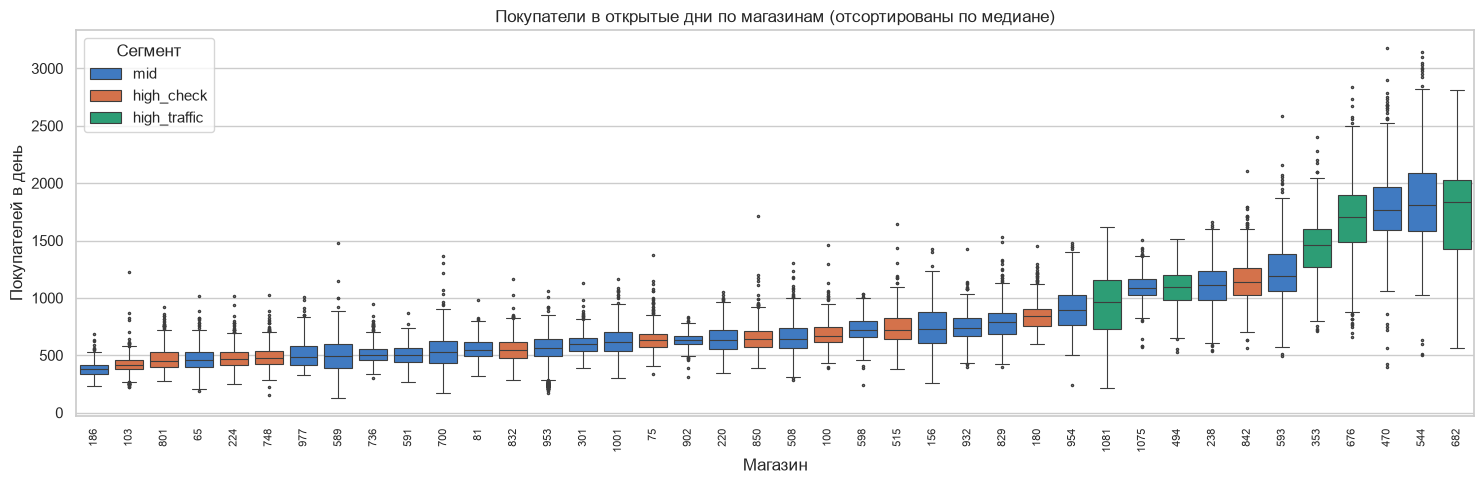

In [9]:
order = open_calendar.groupby("Store")["customers_clean"].median().sort_values().index

fig, ax = plt.subplots(figsize=(15, 5))
sns.boxplot(data=open_calendar.assign(customers=customers_open), x="Store", y="customers", order=order,
            hue="segment", palette=SEGMENT_COLORS, dodge=False, fliersize=1.5, linewidth=0.8, ax=ax)
ax.set(title="Покупатели в открытые дни по магазинам (отсортированы по медиане)",
       xlabel="Магазин", ylabel="Покупателей в день")
ax.tick_params(axis="x", labelrotation=90, labelsize=8)
ax.legend(title="Сегмент")
plt.tight_layout()
plt.show()

Медианы магазинов различаются почти в 5 раз: примерно от 400 до 1800 покупателей в день. При этом сегменты по масштабу не разделяются строго. Магазины `high_traffic` в основном находятся в верхней части распределения, но среди сегмента `mid` тоже есть магазины с высоким потоком - до 1800 покупателей. Сегмент `high_check` охватывает в основном нижнюю и среднюю часть распределения. Разброс внутри магазина тоже разный: у одних магазинов коробка узкая, у других широкая, и у крупных магазинов больше верхних выбросов.

**Для модели:** сегмент не заменяет уровень конкретного магазина, поэтому в признаки нужно добавить именно масштаб магазина (например, скользящее среднее его потока). Метрики по группам нужно сравнивать с учетом масштаба: MAE у магазина на 1800 покупателей несопоставима с MAE у магазина на 400.

### 2.2 Сезонность аддитивная или мультипликативная

Если колебания по дням недели у крупных магазинов больше в абсолютных числах, но такие же в процентах, сезонность мультипликативная: эффекты - это проценты от уровня магазина. Тогда для общей модели на все магазины логично работать с логарифмом или индексом, а не с сырыми значениями.

Амплитуда недельных колебаний - это стандартное отклонение средних по дням недели (понедельник - суббота; воскресенье исключено, так как по воскресеньям работают не все магазины).

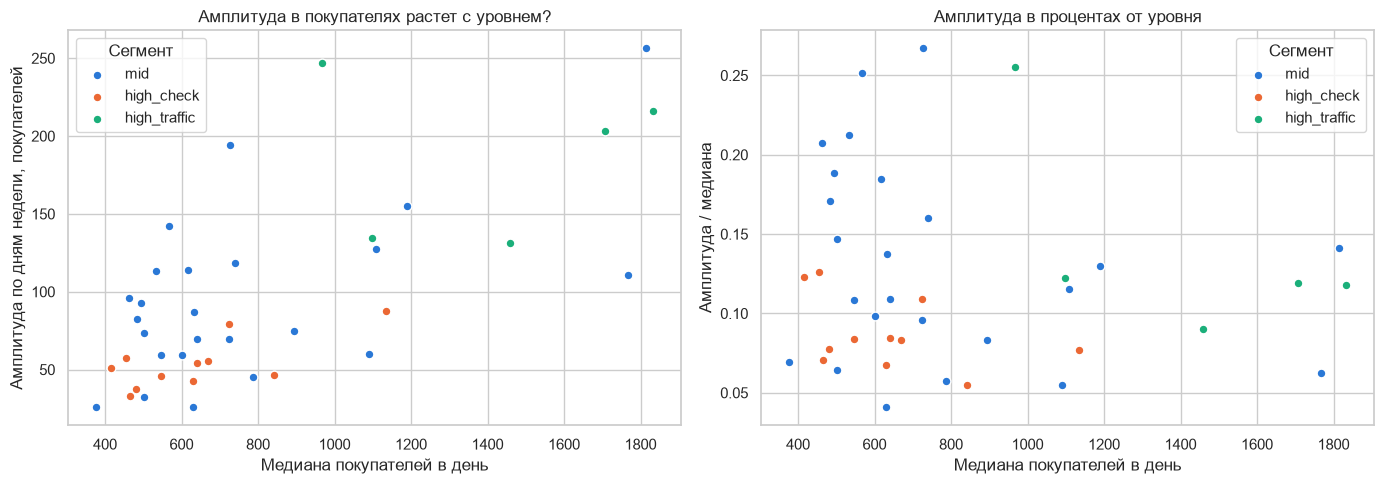

Корреляция Спирмена: 'уровень x амплитуда' = 0.59, 'уровень x относительная амплитуда' = -0.11


In [10]:
weekday_means = (open_calendar[open_calendar["DayOfWeek"] <= 6]
                 .groupby(["Store", "DayOfWeek"])["customers_clean"].mean().astype(float).unstack())
amplitude = pd.DataFrame({
    "level": store_median.astype(float),
    "amplitude": weekday_means.std(axis=1),
}).join(selected["segment"])
amplitude["relative_amplitude"] = amplitude["amplitude"] / amplitude["level"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for segment, color in SEGMENT_COLORS.items():
    part = amplitude[amplitude["segment"] == segment]
    axes[0].scatter(part["level"], part["amplitude"], color=color, s=40, edgecolor="white", label=segment)
    axes[1].scatter(part["level"], part["relative_amplitude"], color=color, s=40, edgecolor="white", label=segment)
axes[0].set(title="Амплитуда в покупателях растет с уровнем?",
            xlabel="Медиана покупателей в день", ylabel="Амплитуда по дням недели, покупателей")
axes[1].set(title="Амплитуда в процентах от уровня",
            xlabel="Медиана покупателей в день", ylabel="Амплитуда / медиана")
for ax in axes:
    ax.legend(title="Сегмент")
plt.tight_layout()
plt.show()

print(f"Корреляция Спирмена: 'уровень x амплитуда' = "
      f"{amplitude['level'].corr(amplitude['amplitude'], method='spearman'):.2f}, "
      f"'уровень x относительная амплитуда' = "
      f"{amplitude['level'].corr(amplitude['relative_amplitude'], method='spearman'):.2f}")

**Cезонность мультипликативная.** Амплитуда недельных колебаний в покупателях растет с уровнем магазина (корреляция Спирмена 0.59), а в процентах от уровня - нет (-0.11). То есть крупный магазин колеблется по дням недели на большее число покупателей, но примерно на ту же долю. При этом относительная амплитуда сильно различается между магазинами (примерно от 4% до 27%) независимо от их масштаба: недельный профиль у каждого магазина свой.

**Для модели:** эффекты дня недели - это проценты от уровня магазина, поэтому общей модели логично работать с логарифмом или индексом целевой, а не с сырыми значениями. А так как недельный профиль индивидуален, один общий признак "день недели" его не опишет: нужны лаги того же дня недели (7 и 14 дней), которые несут профиль конкретного магазина.

### 2.3 Выручка и средний чек

В рамках дизайна проекта у каждого дня должна быть выручка или средний чек. Проверяем, как выручка связана с числом покупателей и насколько стабилен средний чек во времени. Чек сравниваем в виде индекса к среднему чеку каждого магазина: иначе смена состава магазинов в отдельные месяцы (пробелы выгрузки, закрытия) выглядела бы как изменение чека. Если чек стабилен, то выручка почти полностью определяется потоком и как отдельный признак мало что добавит.

Корреляция покупателей и выручки внутри магазина: медиана 0.94, минимум 0.71, максимум 0.98


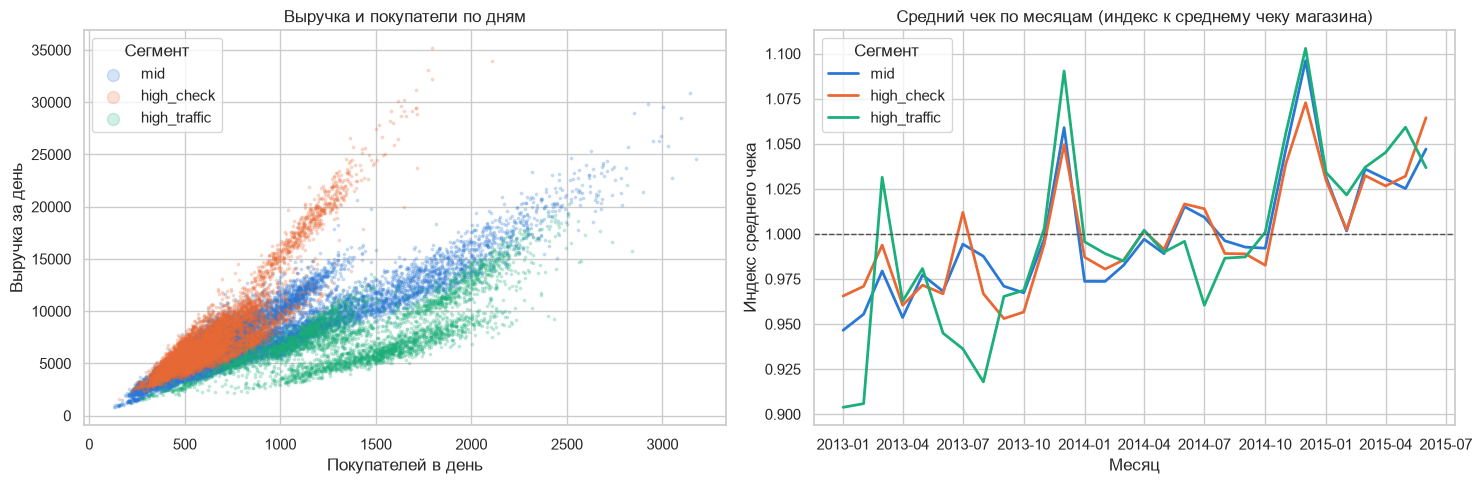

In [11]:
per_store_corr = (open_calendar.groupby("Store")[["customers_clean", "sales_clean"]]
                  .apply(lambda g: g["customers_clean"].astype(float).corr(g["sales_clean"].astype(float))))
print(f"Корреляция покупателей и выручки внутри магазина: медиана {per_store_corr.median():.2f}, "
      f"минимум {per_store_corr.min():.2f}, максимум {per_store_corr.max():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for segment, color in SEGMENT_COLORS.items():
    part = open_calendar[open_calendar["segment"] == segment]
    axes[0].scatter(part["customers_clean"].astype(float), part["sales_clean"].astype(float),
                    s=3, alpha=0.2, color=color, label=segment)
axes[0].set(title="Выручка и покупатели по дням", xlabel="Покупателей в день", ylabel="Выручка за день")
axes[0].legend(title="Сегмент", markerscale=5)

# Индекс чека: чек магазина за месяц, деленный на его средний чек за весь трейн.
# Так смена состава магазинов (пробелы выгрузки, закрытия) не выдается за изменение чека
store_month = (open_calendar.assign(month=open_calendar["Date"].dt.to_period("M"))
               .groupby(["Store", "segment", "month"])[["sales_clean", "customers_clean"]].sum())
store_total = open_calendar.groupby("Store")[["sales_clean", "customers_clean"]].sum()
store_check = (store_total["sales_clean"] / store_total["customers_clean"]).astype(float)
check_index = ((store_month["sales_clean"] / store_month["customers_clean"]).astype(float)
               .div(store_check, level="Store"))
monthly_check = check_index.groupby(["segment", "month"]).mean().unstack(0)
for segment, color in SEGMENT_COLORS.items():
    axes[1].plot(monthly_check.index.to_timestamp(), monthly_check[segment], color=color, linewidth=2, label=segment)
axes[1].axhline(1, color="#52514e", linestyle="--", linewidth=1)
axes[1].set(title="Средний чек по месяцам (индекс к среднему чеку магазина)",
            xlabel="Месяц", ylabel="Индекс среднего чека")
axes[1].legend(title="Сегмент")
plt.tight_layout()
plt.show()

Выручка тесно связана с количеством покупателей: медианная корреляция внутри магазина составляет 0,94, а значения для отдельных магазинов находятся в диапазоне от 0,71 до 0,98. На левом графике это видно по отдельным "лучам" для каждого магазина. Наклон луча связан со средним чеком: при одинаковом количестве покупателей магазины с более высоким средним чеком получают больше выручки. Поэтому у `high_check` лучи в среднем круче, а у `high_traffic` более пологие.

Средний чек во времени меняется медленно и почти одинаково во всех сегментах: он плавно растет (примерно с 0.95 от среднего уровня магазина в начале 2013 года до 1.03-1.06 в 2015 году) и каждый год дает пик в декабре.

**Для модели:** основная информация о выручке уже содержится в количестве покупателей, поэтому лаги выручки не являются обязательными признаками для прогноза `Customers`. Для бизнес-выводов важно, что рост выручки может происходить не только за счет увеличения числа покупателей, но и за счет роста среднего чека. В декабре этот эффект особенно заметен: выручка растет сильнее, чем поток покупателей.

## 3. Недельная сезонность и промоакции

Во всех разделах, где усредняются несколько магазинов, используется индекс (покупатели / медиана магазина) и только открытые дни. Чтобы на средние не влиял состав магазинов, в "обычные" дни включаются понедельник - суббота без государственных праздников: по воскресеньям и в праздники открыта только часть магазинов, и среднее в эти дни считалось бы по другому набору магазинов.

In [12]:
open_calendar["index"] = open_calendar["index"].astype(float)
regular_days = open_calendar[open_calendar["DayOfWeek"].le(6) & open_calendar["StateHoliday"].eq("0")]

### 3.1 Профиль по дням недели

Средний индекс по дням недели в дни без праздников. Серые линии - отдельные магазины, цветная - среднее по сегменту.

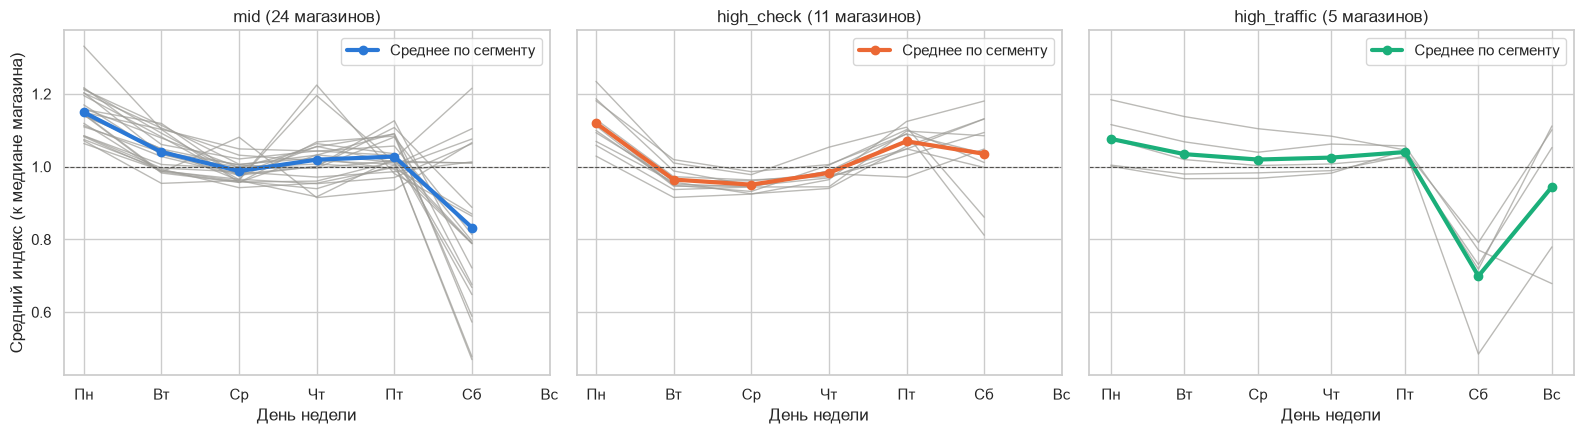

DayOfWeek,Пн,Вт,Ср,Чт,Пт,Сб,Вс
segment,,,,,,,
high_check,1.12,0.96,0.95,0.98,1.07,1.04,NaN
high_traffic,1.08,1.03,1.02,1.02,1.04,0.70,0.94
mid,1.15,1.04,0.99,1.02,1.03,0.83,NaN


In [13]:
DAY_NAMES = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]
no_holiday = open_calendar[open_calendar["StateHoliday"].eq("0")]
dow_profile = no_holiday.groupby(["segment", "Store", "DayOfWeek"])["index"].mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, (segment, color) in zip(axes, SEGMENT_COLORS.items()):
    segment_profile = dow_profile.loc[segment]
    for store, profile in segment_profile.groupby(level="Store"):
        ax.plot(profile.index.get_level_values("DayOfWeek"), profile, color="#9e9d98", linewidth=1, alpha=0.7)
    mean_profile = segment_profile.groupby(level="DayOfWeek").mean()
    ax.plot(mean_profile.index, mean_profile, color=color, linewidth=3, marker="o", label="Среднее по сегменту")
    ax.axhline(1, color="#52514e", linestyle="--", linewidth=0.8)
    ax.set_xticks(range(1, 8), DAY_NAMES)
    ax.set(title=f"{segment} ({segment_profile.index.get_level_values('Store').nunique()} магазинов)",
           xlabel="День недели")
    ax.legend(loc="upper right")
axes[0].set_ylabel("Средний индекс (к медиане магазина)")
plt.tight_layout()
plt.show()

dow_profile.groupby(["segment", "DayOfWeek"]).mean().unstack().round(2).rename(columns=dict(zip(range(1, 8), DAY_NAMES)))

Во всех сегментах понедельник - самый сильный день (индекс 1.08-1.15), середина недели проседает, к пятнице поток снова растет. Главное различие между сегментами - суббота: в `mid` она заметно слабее обычного дня (0.83), в `high_check` - выше обычного (1.04), а в `high_traffic` - самый слабый день недели (0.70), причем воскресенье у этих магазинов сильнее субботы (0.94). Внутри сегмента профили магазинов тоже различаются, особенно в субботу: в `mid` индекс субботы у отдельных магазинов - от ~0.5 до ~1.2.

**Для модели:** эффект дня недели зависит от сегмента и от конкретного магазина. Признака "день недели" недостаточно - нужны лаги того же дня недели, которые несут профиль конкретного магазина, или взаимодействие "день недели x сегмент".

### 3.2 Промоакции и недельный цикл

Сначала проверяем, как устроено расписание промоакций: одинаково ли оно у всех магазинов и чередуются ли недели с промоакцией и без. Затем - насколько промоакция меняет поток и профиль по дням недели.

Дней, когда промоакции одинаковы у всех магазинов: 100.0%
Дни недели с промоакцией: [1, 2, 3, 4, 5]
Недель с промоакцией: 53%; неделя отличается от предыдущей по наличию промоакции в 90% случаев


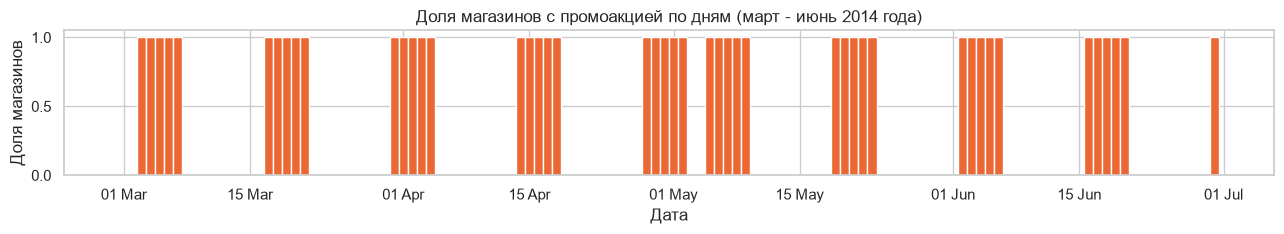

In [14]:
promo_days = calendar[calendar["day_status"].isin(["open", "closed"])]
promo_share = promo_days.groupby("Date")["Promo"].mean().astype(float)
print(f"Дней, когда промоакции одинаковы у всех магазинов: {promo_share.isin([0, 1]).mean():.1%}")
print(f"Дни недели с промоакцией: {sorted(promo_days.loc[promo_days['Promo'].eq(1), 'DayOfWeek'].unique().tolist())}")

promo_by_week = promo_share.groupby(promo_share.index.to_period("W")).max()
switches = promo_by_week.ne(promo_by_week.shift()).iloc[1:].mean()
print(f"Недель с промоакцией: {promo_by_week.mean():.0%}; неделя отличается от предыдущей по наличию промоакции в {switches:.0%} случаев")

fig, ax = plt.subplots(figsize=(13, 2.5))
sample = promo_share.loc["2014-03-01":"2014-06-30"]
ax.bar(sample.index, sample, width=1, color="#eb6834")
ax.set(title="Доля магазинов с промоакцией по дням (март - июнь 2014 года)", ylabel="Доля магазинов", xlabel="Дата")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.tight_layout()
plt.show()

Промоакции устроены как общий календарь сети: в каждый день промоакция либо у всех магазинов, либо ни у одного (100% дней), и проводится она только с понедельника по пятницу. Недели с промоакцией и без в основном чередуются: промоакция идет в 53% недель, и в 90% случаев неделя отличается от предыдущей. Чередование не строгое: иногда промоакция идет две недели подряд (например, в конце апреля - начале мая 2014 года на графике).

**Для модели:** промоакция создает двухнедельный цикл - лаг 7 дней почти всегда указывает на неделю с противоположным промо. Поскольку промоакция - общий план сети, в реальном бизнесе его расписание известно заранее, и его можно использовать как признак на будущие дни, если расписание промоакции передается на вход прогноза.

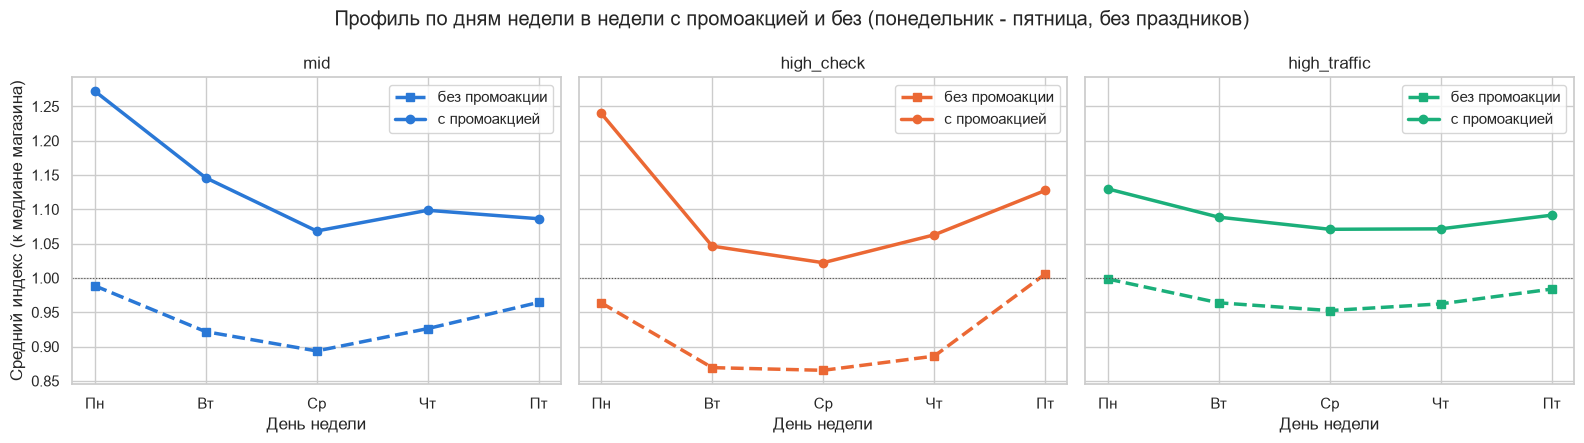

Эффект промоакции (понедельник - пятница): медиана по магазинам сегмента
segment
high_check      +21.0%
high_traffic    +15.5%
mid             +21.4%
По всем магазинам: от +4.6% до +40.8%


In [15]:
weekdays = regular_days[regular_days["DayOfWeek"].le(5)]
promo_profile = weekdays.groupby(["segment", "Promo", "DayOfWeek"])["index"].mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, (segment, color) in zip(axes, SEGMENT_COLORS.items()):
    for promo, style, marker in [(0, "--", "s"), (1, "-", "o")]:
        profile = promo_profile.loc[(segment, promo)]
        ax.plot(profile.index, profile, color=color, linestyle=style, linewidth=2.5, marker=marker,
                label="с промоакцией" if promo else "без промоакции")
    ax.axhline(1, color="#52514e", linestyle=":", linewidth=0.8)
    ax.set_xticks(range(1, 6), DAY_NAMES[:5])
    ax.set(title=segment, xlabel="День недели")
    ax.legend()
axes[0].set_ylabel("Средний индекс (к медиане магазина)")
fig.suptitle("Профиль по дням недели в недели с промоакцией и без (понедельник - пятница, без праздников)")
plt.tight_layout()
plt.show()

promo_effect = (weekdays.groupby(["segment", "Store", "Promo"])["index"].mean().unstack("Promo")
                .pipe(lambda d: d[1] / d[0] - 1).rename("promo_effect"))
print("Эффект промоакции (понедельник - пятница): медиана по магазинам сегмента")
print(promo_effect.groupby(level="segment").median().map("{:+.1%}".format).to_string())
print(f"По всем магазинам: от {promo_effect.min():+.1%} до {promo_effect.max():+.1%}")

Промоакции - один из самых сильных факторов: в дни промоакций поток в среднем выше на 21% в `mid` и `high_check` и на 15.5% в `high_traffic`, а по отдельным магазинам - от +5% до +41%. Сильнее всего промоакция поднимает понедельник (в `mid` индекс понедельника 1.27 с промо против 0.99 без него). Форма недельного профиля с промоакцией и без похожа, различается в основном уровень.

**Для модели:** признак промоакция обязателен, а его эффект индивидуален для магазина. Без него модель предсказывала бы средний уровень между неделями с промоакцией и без и ошибалась бы примерно на 10% в обе стороны - занижая недели с промоакциями и завышая остальные.

### 3.3 Устойчивость недельного профиля

Если профиль по дням недели одинаков во все месяцы и годы, для модели достаточно признака "день недели". Если он меняется, нужны взаимодействия (день недели x месяц) или модель, которая находит их сама.

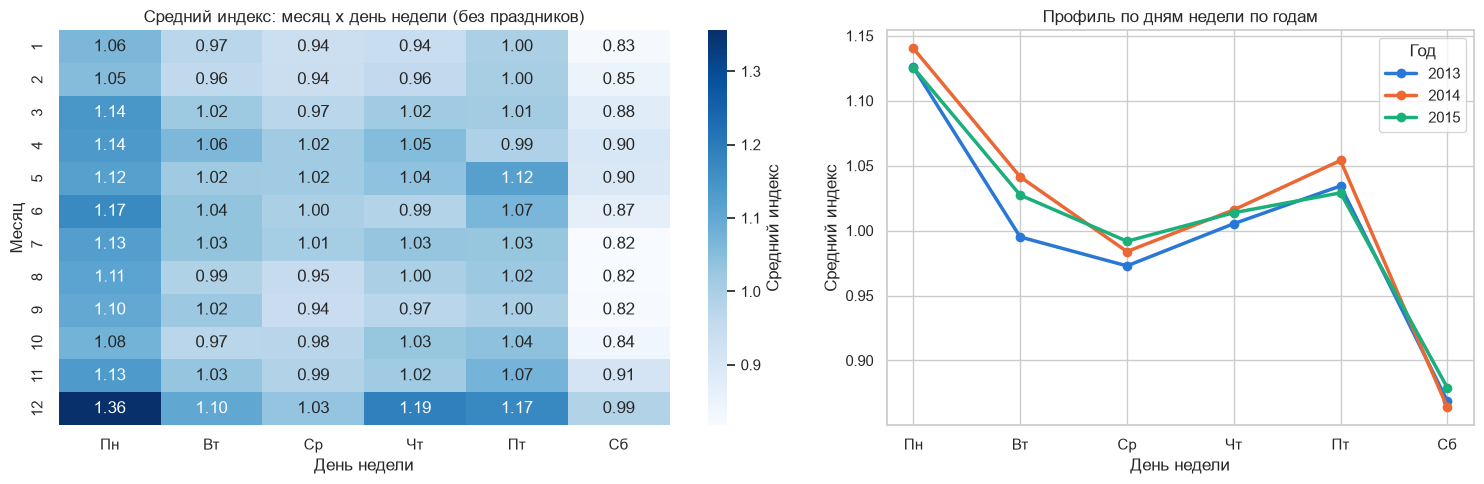

In [16]:
month_dow = (regular_days.assign(month=regular_days["Date"].dt.month)
             .groupby(["month", "DayOfWeek"])["index"].mean().unstack())
year_dow = (regular_days.assign(year=regular_days["Date"].dt.year)
            .groupby(["year", "DayOfWeek"])["index"].mean().unstack())

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1.3, 1]})
sns.heatmap(month_dow.rename(columns=dict(zip(range(1, 7), DAY_NAMES))), annot=True, fmt=".2f", cmap="Blues",
            cbar_kws={"label": "Средний индекс"}, ax=axes[0])
axes[0].set(title="Средний индекс: месяц x день недели (без праздников)", xlabel="День недели", ylabel="Месяц")
for (year, profile), color in zip(year_dow.iterrows(), ["#2a78d6", "#eb6834", "#1baf7a"]):
    axes[1].plot(profile.index, profile, color=color, linewidth=2.5, marker="o", label=str(year))
axes[1].set_xticks(range(1, 7), DAY_NAMES[:6])
axes[1].set(title="Профиль по дням недели по годам", xlabel="День недели", ylabel="Средний индекс")
axes[1].legend(title="Год")
plt.tight_layout()
plt.show()

Недельный профиль устойчив: во все месяцы понедельник - сильнейший день, суббота - самый слабый, а профили 2013, 2014 и 2015 годов почти совпадают. Заметно меняется только декабрь: растут все дни недели (понедельник до 1.36, четверг и пятница до 1.17-1.19), а суббота приближается к обычному уровню (0.99). В ноябре и декабре суббота вообще сильнее, чем в остальные месяцы.

**Для модели:** профиль дня недели можно выучить по истории, он не меняется от года к году. Взаимодействие "день недели x месяц" нужно в основном для декабря; модель на деревьях найдет его сама, если есть признаки дня недели и месяца.

### 3.4 Автокорреляция

Автокорреляция на лаге k показывает, насколько значение показателя сегодня связано с его значением k дней назад. Например, высокая автокорреляция на лаге 7 означает, что значение сегодня часто похоже на значение того же магазина неделю назад.

Анализ автокорреляции помогает понять, какие прошлые значения полезно использовать при прогнозировании, и поэтому обосновывает выбор лаговых признаков.

Автокорреляцию рассчитываем только по открытым дням. Закрытые дни с нулевым числом покупателей исключаем, поскольку регулярные закрытия, например по воскресеньям, сами по себе создавали бы искусственную связь между значениями через 7 дней.

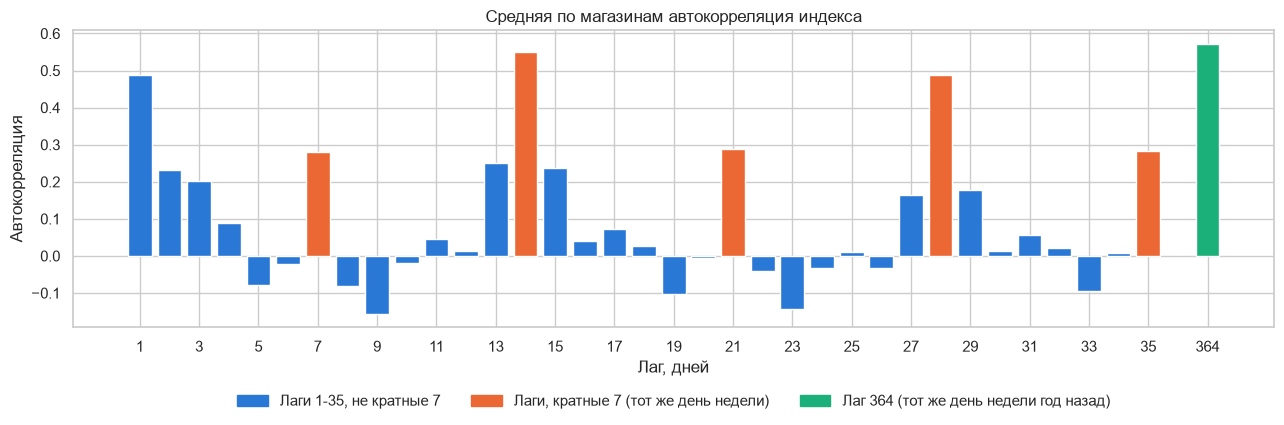

Средняя автокорреляция: {1: 0.49, 6: -0.02, 7: 0.28, 13: 0.25, 14: 0.55, 21: 0.29, 28: 0.49, 364: 0.57}


In [17]:
LAGS = list(range(1, 36)) + [364]
daily_index = (calendar.assign(index=calendar["index"].astype(float).where(calendar["day_status"].eq("open")))
               .pivot(index="Date", columns="Store", values="index"))   # NaN во все дни, кроме открытых
acf = pd.DataFrame({lag: daily_index.apply(lambda s: s.autocorr(lag)) for lag in LAGS})

mean_acf = acf.mean()
fig, ax = plt.subplots(figsize=(13, 4.5))
short = mean_acf.drop(364)
ax.bar(short.index, short, color=["#eb6834" if lag % 7 == 0 else "#2a78d6" for lag in short.index])
ax.bar(37, mean_acf[364], color="#1baf7a")
ax.set_xticks(list(range(1, 36, 2)) + [37], [str(lag) for lag in range(1, 36, 2)] + ["364"])
ax.set(title="Средняя по магазинам автокорреляция индекса",
       xlabel="Лаг, дней", ylabel="Автокорреляция")
ax.legend(handles=[Patch(color="#2a78d6", label="Лаги 1-35, не кратные 7"),
                   Patch(color="#eb6834", label="Лаги, кратные 7 (тот же день недели)"),
                   Patch(color="#1baf7a", label="Лаг 364 (тот же день недели год назад)")],
          loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False)
plt.tight_layout()
plt.show()

print("Средняя автокорреляция:", mean_acf[[1, 6, 7, 13, 14, 21, 28, 364]].round(2).to_dict())

Автокорреляция показывает двухнедельный цикл: лаги 14 и 28 дней (0.55 и 0.49) коррелируют с текущим днем почти вдвое сильнее, чем лаги 7 и 21 (0.28 и 0.29). Лаги 14 и 28 - тот же день недели и та же фаза промоакции, лаги 7 и 21 - тот же день недели, но, как правило, противоположная фаза промоакции. Лаг 1 тоже высокий (0.49), лаг 6 - около нуля. Лаг 364 (тот же день недели год назад) - самый высокий (0.57): годовая сезонность сильная.

**Для модели:**
- при прогнозе на 7 дней вперед лаги 1-6 для последних дней горизонта неизвестны, поэтому основу составят лаги от 7 дней;
- самые информативные из них - лаги 14 и 28 (та же фаза промоакции). Лаг 7 полезен только вместе с признаком промоакции, иначе он сравнивает неделю с промоакцией с неделей без нее. Это важно и для бейзлайна: наивный прогноз "как неделю назад" будет систематически ошибаться из-за чередования наличия и отсутствия промоакций;
- лаг 364 сильный, но у 9 магазинов он пуст для июля 2015 года (раздел 1.2), поэтому основным признаком он быть не может.

## 4. Динамика по времени и тренд

Используются те же индекс и "обычные" дни (понедельник - суббота без праздников), что и в разделе 3. Для сравнения с ноутбуком 01 считаем рост год к году каждого магазина по той же формуле: средний поток на открытый день за 01.01-19.06 2015 года к тем же датам 2014 года.

In [18]:
growth_windows = {"2014": (pd.Timestamp("2014-01-01"), TRAIN_END - pd.DateOffset(years=1)),
                  "2015": (pd.Timestamp("2015-01-01"), TRAIN_END)}
window_mean = {year: open_calendar[open_calendar["Date"].between(start, end)]
                     .groupby("Store")["customers_clean"].mean().astype(float)
               for year, (start, end) in growth_windows.items()}
store_growth = (window_mean["2015"] / window_mean["2014"] - 1).rename("growth")

### 4.1 Общая динамика

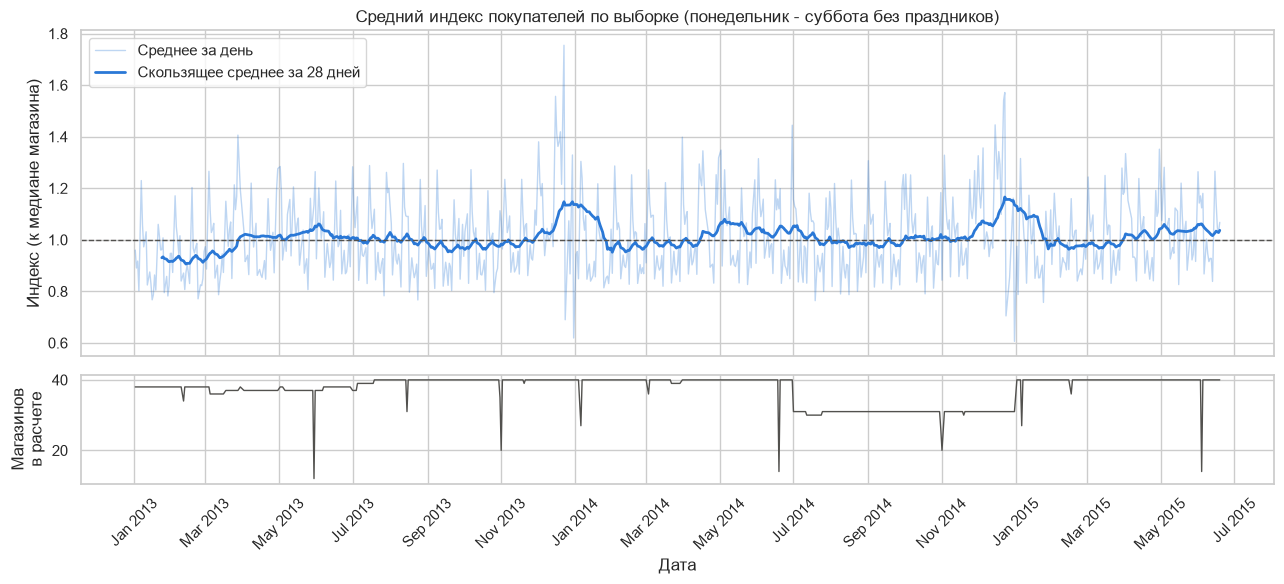

Средний индекс по годам: {2013: 0.999, 2014: 1.015, 2015: 1.009}
Рост за 01.01-19.06 2015 года к тем же датам 2014 года: медиана по магазинам +0.3%, от -20.9% до +9.7%


In [19]:
network_index = regular_days.groupby("Date")["index"].mean()
stores_in_mean = regular_days.groupby("Date")["Store"].nunique()

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
axes[0].plot(network_index.index, network_index, color="#2a78d6", alpha=0.3, linewidth=1, label="Среднее за день")
axes[0].plot(network_index.rolling(28, min_periods=20).mean(), color="#2a78d6", linewidth=2,
             label="Скользящее среднее за 28 дней")
axes[0].axhline(1, color="#52514e", linestyle="--", linewidth=1)
axes[0].set(title="Средний индекс покупателей по выборке (понедельник - суббота без праздников)",
            ylabel="Индекс (к медиане магазина)")
axes[0].legend(loc="upper left")
axes[1].plot(stores_in_mean.index, stores_in_mean, color="#52514e", linewidth=1)
axes[1].set(ylabel="Магазинов\nв расчете", xlabel="Дата")
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(axes[1].get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()

yearly = regular_days.groupby(regular_days["Date"].dt.year)["index"].mean()
print("Средний индекс по годам:", yearly.round(3).to_dict())
print(f"Рост за 01.01-19.06 2015 года к тем же датам 2014 года: медиана по магазинам {store_growth.median():+.1%}, "
      f"от {store_growth.min():+.1%} до {store_growth.max():+.1%}")

Общего тренда у выборки нет: средний индекс по годам - 1.00 (2013), 1.02 (2014) и 1.01 (первая половина 2015), а медианный рост магазина за 01.01-19.06 2015 года к тем же датам 2014 года - всего +0.3%. Скользящее среднее держится около 1, отклоняясь в основном из-за сезонности: подъем в декабре (до ~1.15) и спад в январе - феврале. Отдельные дни перед Рождеством дают индекс до 1.6-1.75. Нижний график показывает, что во втором полугодии 2014 года в расчете 31 магазин вместо 40 (пробел выгрузки у 9 магазинов); индекс ослабляет влияние смены состава на средний уровень.

**Для модели:** общий временной тренд как признак не нужен - уровень задается магазином, а не временем. При этом рост год к году по отдельным магазинам заметно различается: от -20.9% до +9.7% (строка под графиком), поэтому уровень спроса лучше определять по недавней истории конкретного магазина, а не по общему временному тренду всей выборки.

### 4.2 Ряды по магазинам

Сначала обзор всех 40 магазинов: средний индекс по неделям (разрывы линии - периоды без данных или закрытия). Затем подробный разбор нескольких показательных магазинов в исходных единицах.

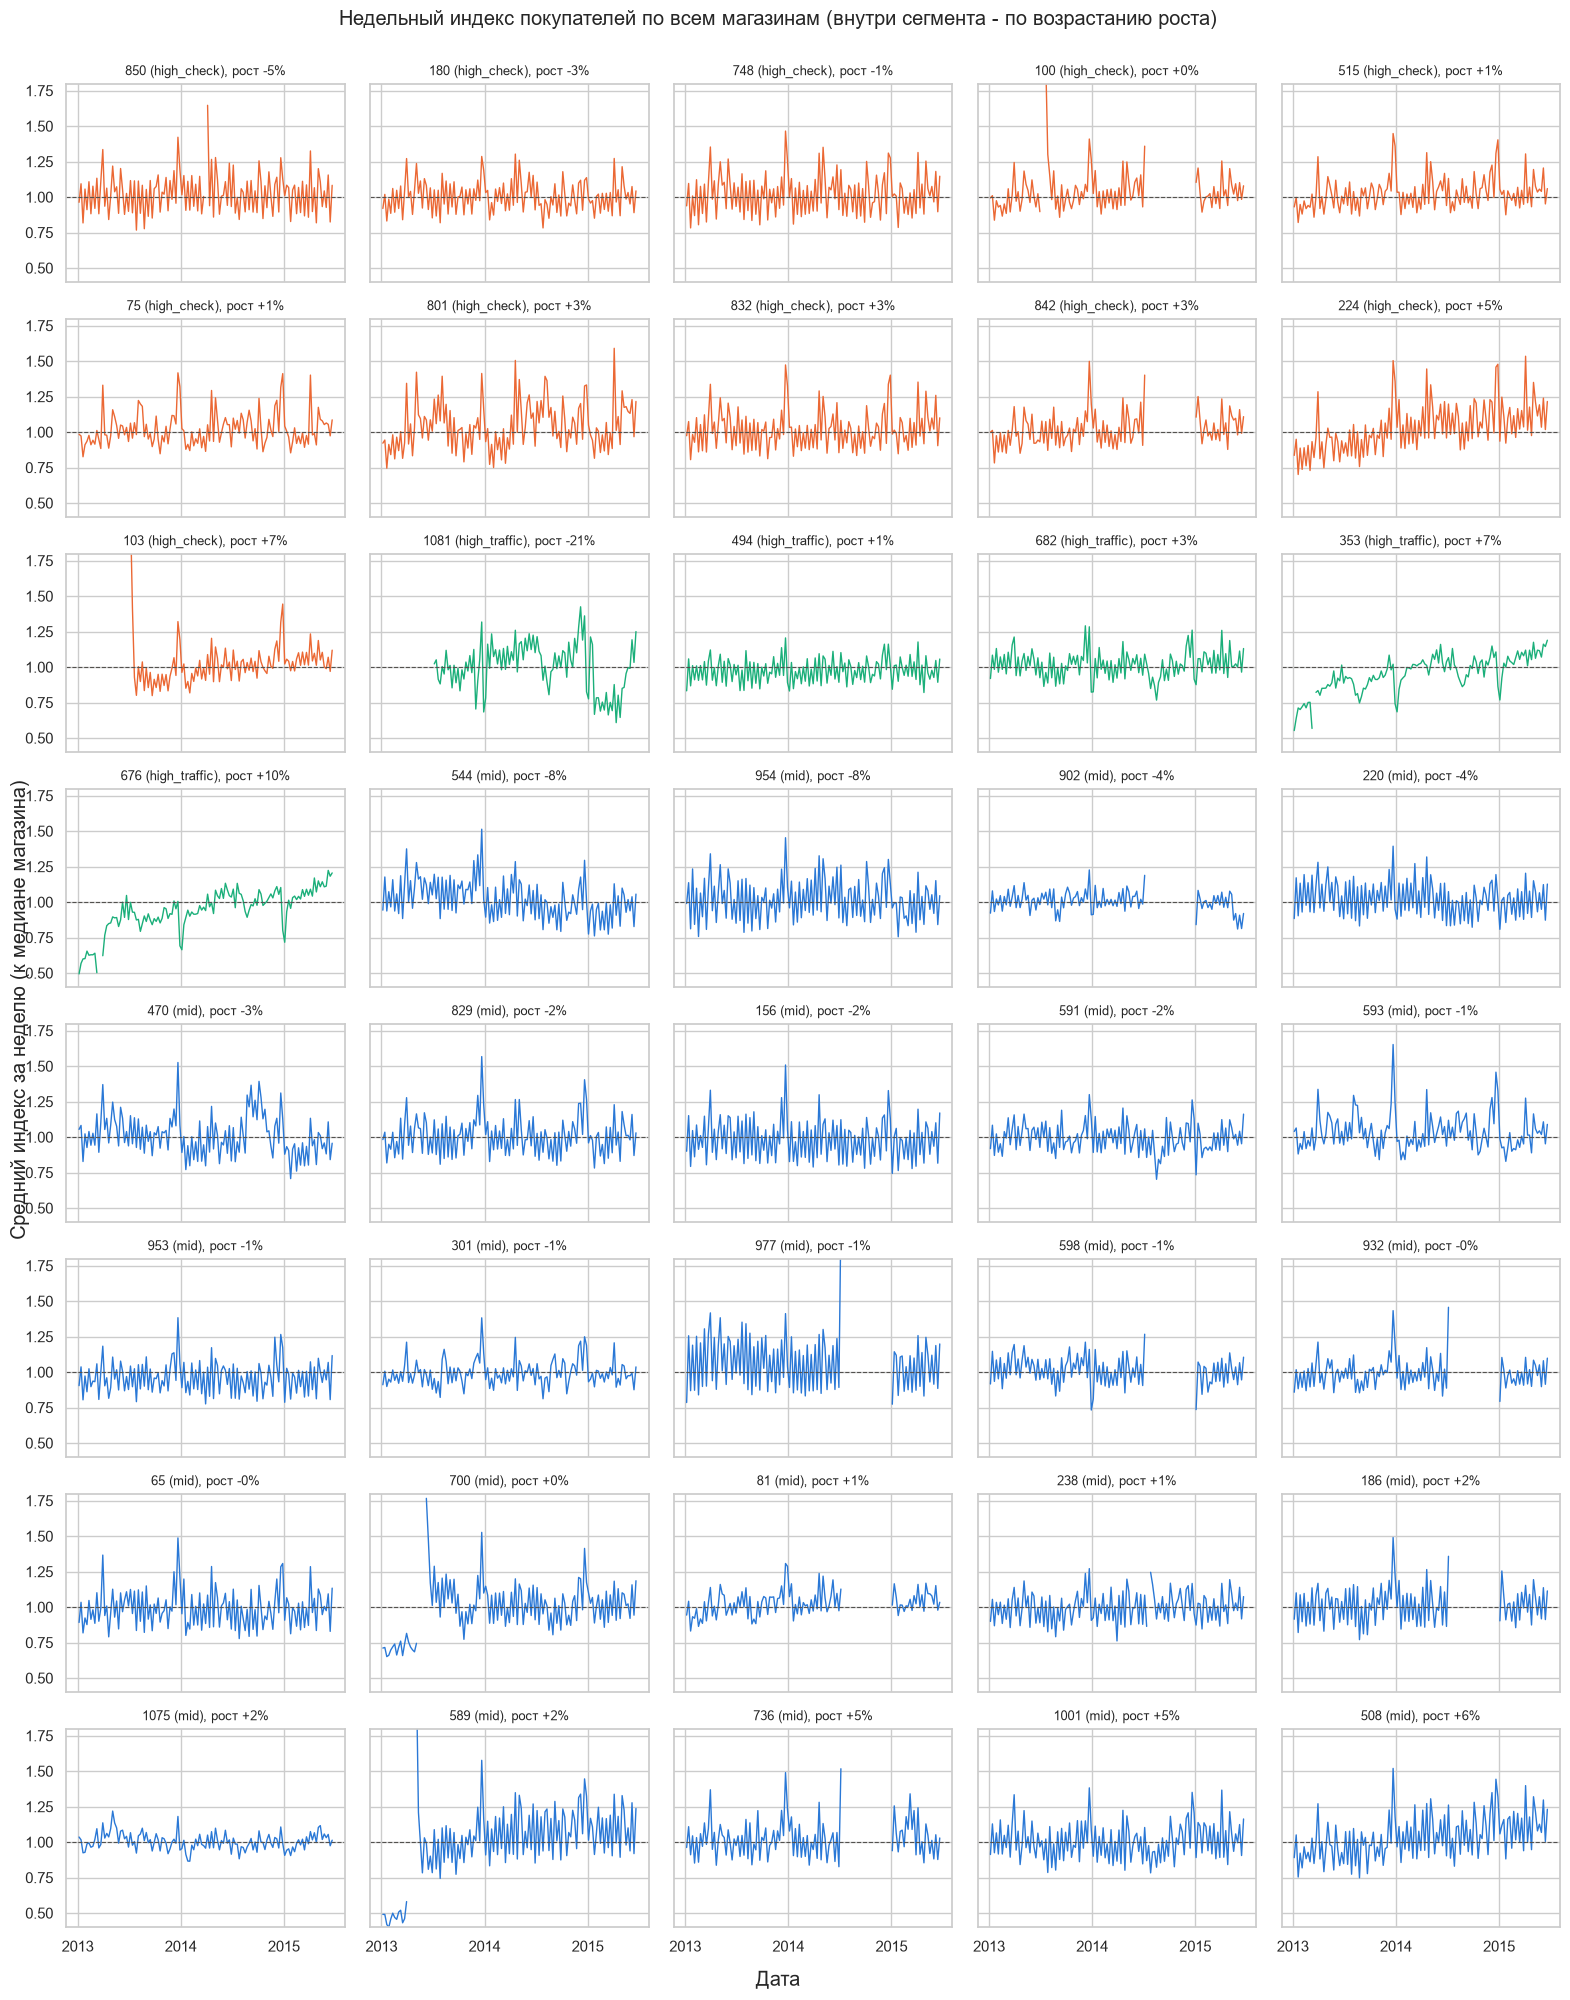

In [20]:
weekly_index = (regular_days.set_index("Date").groupby("Store")["index"].resample("W").mean())
grid_order = (selected.loc[store_order].join(store_growth)
              .sort_values(["segment", "growth"]).index.tolist())

fig, axes = plt.subplots(8, 5, figsize=(16, 20), sharex=True, sharey=True)
for ax, store in zip(axes.flat, grid_order):
    series = weekly_index.loc[store]
    segment = selected.loc[store, "segment"]
    ax.plot(series.index, series, color=SEGMENT_COLORS[segment], linewidth=1)
    ax.axhline(1, color="#52514e", linestyle="--", linewidth=0.8)
    ax.set_title(f"{store} ({segment}), рост {store_growth[store]:+.0%}", fontsize=9)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_ylim(0.4, 1.8)
fig.supylabel("Средний индекс за неделю (к медиане магазина)")
fig.supxlabel("Дата")
fig.suptitle("Недельный индекс покупателей по всем магазинам (внутри сегмента - по возрастанию роста)", y=1.0)
plt.tight_layout()
plt.show()

In [21]:
# Что остается от последней недели перед пробелом выгрузки у магазинов с пробелом
gap_stores = calendar.loc[calendar["day_status"].eq("missing_export"), "Store"].unique()
gap_start = calendar.loc[calendar["day_status"].eq("missing_export"), "Date"].min()
last_week = pd.date_range(gap_start - pd.Timedelta(days=gap_start.dayofweek), periods=7)
print(f"Пробел начинается {gap_start.date()} ({DAY_NAMES[gap_start.dayofweek]}), "
      f"последняя неделя перед ним: {last_week[0].date()} - {last_week[-1].date()}")
(calendar[calendar["Date"].isin(last_week) & calendar["Store"].isin(gap_stores) & calendar["day_status"].eq("open")]
 .assign(index=lambda d: d["index"].astype(float))
 .groupby("Date").agg(магазинов=("Store", "nunique"), промо=("Promo", "max"), средний_индекс=("index", "mean"))
 .round(2))

Пробел начинается 2014-07-01 (Вт), последняя неделя перед ним: 2014-06-30 - 2014-07-06


,магазинов,промо,средний_индекс
Date,,,
2014-06-30,9,1,1.42


Сетка показывает все 40 рядов в одной шкале, и на ней видны три группы закономерностей.

**Общее почти для всех магазинов.** Узкий пик в неделях перед Рождеством (индекс около 1.3-1.5) и провал сразу после Нового года - самая устойчивая закономерность выборки. Почти у всех магазинов есть "пила" - взлеты и падения от недели к неделе: это чередование недель с промоакцией и без (раздел 3.2). Размах взлетов и падений у магазинов разный: у 977 около +-0.25, у 1075 пилы почти нет - эффект промоакции индивидуален.

**Индивидуальные события.**
- Всплеск сразу после длинного закрытия: 100, 103, 589, 700, 850 (раздел 1.4).
- Смена уровня после ремонта: у 589, 700, 676 и 353 до закрытия в начале 2013 года индекс около 0.5-0.75, а после него - около 1. Ремонт не только прерывает ряд, но и переводит магазин на другой уровень.
- Устойчивые тренды: рост у 676 и 353 (и после ремонта), умеренный рост у 224 и 508, снижение у 544.
- Временные эпизоды: провал у 1081 в начале 2015 года с восстановлением к июню, подъем у 470 осенью 2014 года.

**Артефакты графика, а не события.** Одиночные пики сразу перед пробелом выгрузки (977, 932, 736, 186) - это неполная неделя. Проверка под графиком показывает, что пробел начинается во вторник 1 июля 2014 года и от последней недели перед ним у магазинов с пробелом остается только понедельник 30 июня - самый сильный день недели (раздел 3.1) и к тому же день с промоакцией (раздел 3.2). Среднее за такую "неделю" из одного дня завышено. Самые высокие пики после открытия обрезаны верхней границей оси.

**Для модели:** уровень магазина нужно брать из недавней истории. История до длинного закрытия - другой режим: лаги и скользящие средние не должны протягиваться через закрытие (это уже заложено в статусе `absent`), а после открытия уровень набирается заново. Эффект промоакции индивидуален, поэтому нужны и признак промоакции, и лаги той же фазы промоакции (раздел 3.4). Декабрьский пик общий для всех - его описывают календарные признаки.

Показательные магазины выбираются по правилам, а не вручную: типичный магазин каждого сегмента (рост ближе всего к медиане сегмента), магазины с самым сильным падением и самым сильным ростом и магазин, появившийся в данных позже. Показаны исходные значения: число покупателей в открытые дни и скользящее среднее за 28 дней; цветом залиты периоды, когда точки нет (оранжевый) и пробелы выгрузки (синий).

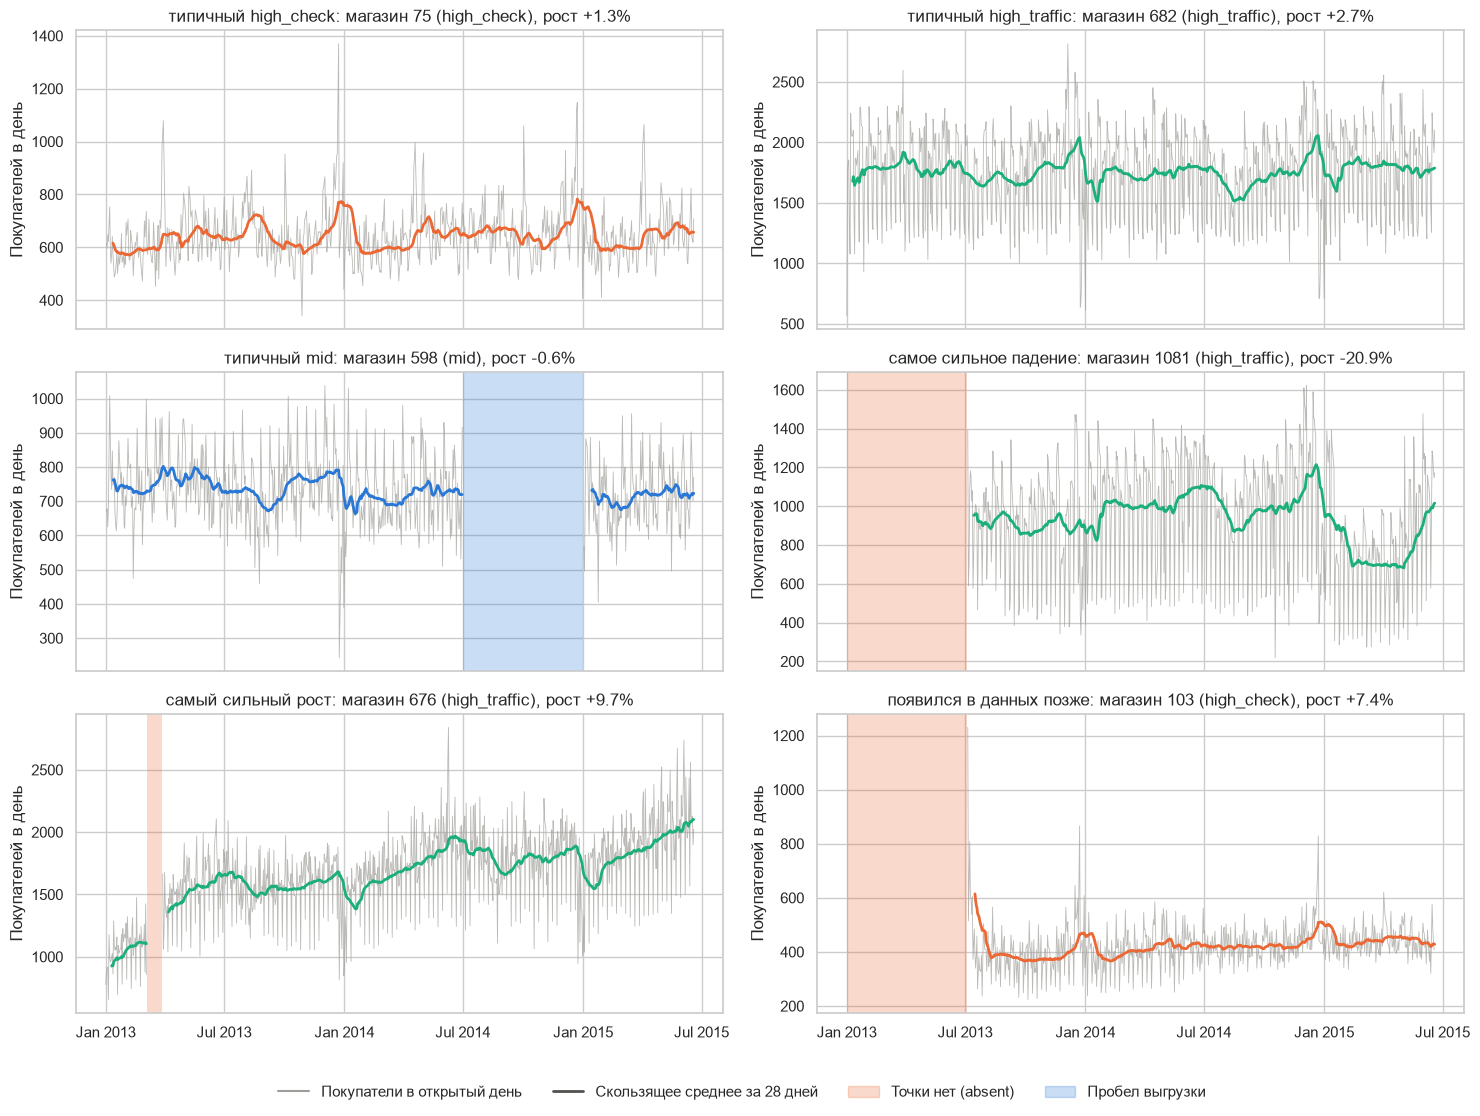

In [22]:
segment_growth = selected[["segment"]].join(store_growth)
typical = (segment_growth.assign(distance=lambda d: (d["growth"] - d.groupby("segment")["growth"].transform("median")).abs())
           .sort_values("distance").groupby("segment").head(1))
showcase = {f"типичный {row.segment}": store for store, row in typical.iterrows()}
showcase["самое сильное падение"] = store_growth.idxmin()
showcase["самый сильный рост"] = store_growth.idxmax()
showcase["появился в данных позже"] = selected.index[selected["has_left_censored"]].min()


def shade_periods(ax: plt.Axes, store_calendar: pd.DataFrame, status: str, color: str) -> None:
    '''Заливает на графике непрерывные периоды с заданным статусом дня.'''
    mask = store_calendar["day_status"].eq(status)
    period_id = mask.ne(mask.shift()).cumsum()[mask]
    for _, dates in store_calendar.loc[mask, "Date"].groupby(period_id):
        ax.axvspan(dates.min(), dates.max(), color=color, alpha=0.25, linewidth=0)


fig, axes = plt.subplots(3, 2, figsize=(15, 11), sharex=True)
for ax, (label, store) in zip(axes.flat, showcase.items()):
    store_calendar = calendar[calendar["Store"] == store]
    # закрытые по расписанию дни пропускаем; там, где точки нет или нет данных, - NaN, и линия прерывается
    daily = (store_calendar[store_calendar["day_status"] != "closed"]
             .set_index("Date")["customers_clean"].astype(float))
    ax.plot(daily.index, daily, color="#9e9d98", linewidth=0.6, alpha=0.7)
    ax.plot(daily.rolling("28D", min_periods=10).mean().where(daily.notna()),
            color=SEGMENT_COLORS[selected.loc[store, "segment"]], linewidth=2)
    shade_periods(ax, store_calendar, "absent", STATUS_COLORS["absent"])
    shade_periods(ax, store_calendar, "missing_export", STATUS_COLORS["missing_export"])
    ax.set(title=f"{label}: магазин {store} ({selected.loc[store, 'segment']}), рост {store_growth[store]:+.1%}",
           ylabel="Покупателей в день")
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7)))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.legend(handles=[plt.Line2D([], [], color="#9e9d98", label="Покупатели в открытый день"),
                    plt.Line2D([], [], color="#52514e", linewidth=2, label="Скользящее среднее за 28 дней"),
                    Patch(color=STATUS_COLORS["absent"], alpha=0.25, label="Точки нет (absent)"),
                    Patch(color=STATUS_COLORS["missing_export"], alpha=0.25, label="Пробел выгрузки")],
           loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

Типичные магазины всех трех сегментов (75, 598, 682) в целом сохраняют примерно один и тот же уровень спроса на протяжении всего периода. При этом у них повторяется сезонный рисунок: заметный подъем в декабре и резкое снижение в первые дни января. Магазин 676 с самым сильным ростом (+9.7%) показывает настоящий тренд: поток вырос примерно с 1000 до 2000 покупателей в день за 2.5 года. А магазин 1081 с "самым сильным падением" (-20.9%) на самом деле пережил временный провал: в начале 2015 года поток упал примерно с 1000 до 700 покупателей и к июню почти восстановился. Рост год к году поймал этот эпизод как падение. Магазин 103, появившийся в данных позже, открылся с пиком (около 600 покупателей), затем опустился примерно до 400 и дальше медленно рос.

**Для модели:** рост год к году - хорошая характеристика для отбора, но не описание траектории: за одним числом может стоять и тренд, и временный эпизод. Для прогноза на неделю вперед важен текущий уровень магазина, а не среднее за год. Магазин 1081 к концу трейна восстанавливается после провала: признаки по недавней истории еще "помнят" провал и в начале отложенного периода могут занижать прогноз. Это трудный случай, который стоит отдельно посмотреть при разборе ошибок.

### 4.3 Тренд

Тренд оцениваем с помощью центрированного скользящего среднего недельного индекса за 52 недели. В одном окне находится ровно год данных, поэтому сезонные колебания внутри года сглаживаются, а более долгосрочные изменения уровня спроса становятся заметнее. 

У этого подхода есть ограничение: для первых и последних 26 недель ряда тренд не рассчитывается, потому что для центрированного окна не хватает наблюдений с одной из сторон. 

Магазины сгруппированы по терцилям роста из ноутбука 01, чтобы проверить, что терцили действительно различаются по тренду.

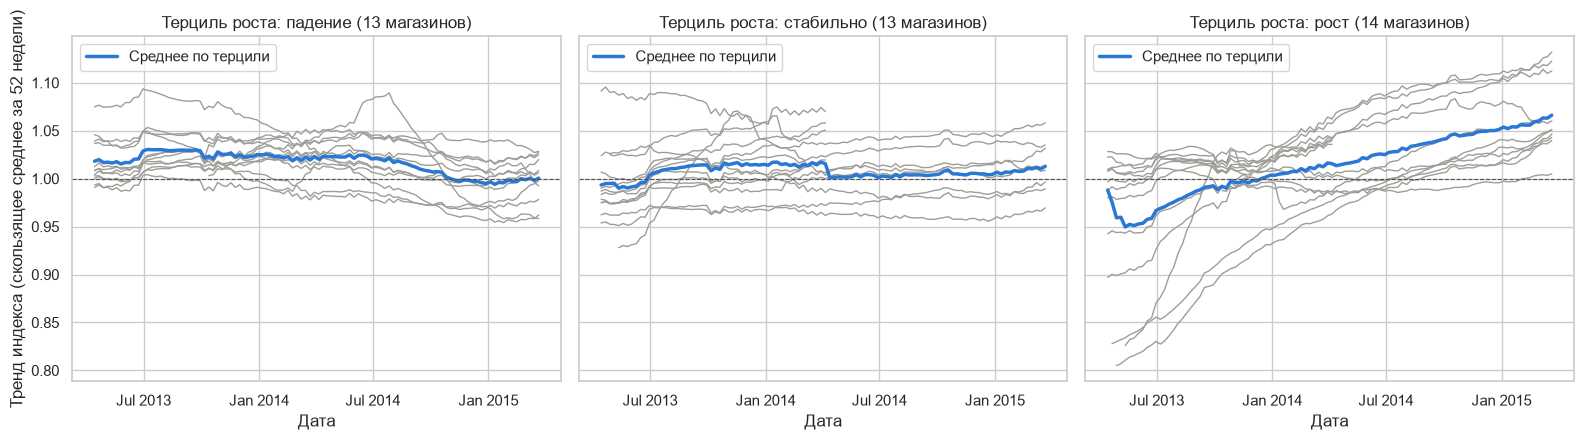

Последняя неделя, где определен тренд: 2015-03-22
Корреляция Спирмена изменения тренда за год и роста год к году: 0.95


In [23]:
trend = (weekly_index.groupby(level="Store")
         .transform(lambda s: s.rolling(52, center=True, min_periods=40).mean()))
trend_frame = trend.rename("trend").reset_index().join(selected[["growth_tercile", "segment"]], on="Store")

TERCILES = ["падение", "стабильно", "рост"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, tercile in zip(axes, TERCILES):
    part = trend_frame[trend_frame["growth_tercile"] == tercile]
    for store, store_trend in part.groupby("Store"):
        ax.plot(store_trend["Date"], store_trend["trend"], color="#9e9d98", linewidth=1)
    mean_trend = part.groupby("Date")["trend"].mean()
    ax.plot(mean_trend.index, mean_trend, color="#2a78d6", linewidth=2.5, label="Среднее по терцили")
    ax.axhline(1, color="#52514e", linestyle="--", linewidth=0.8)
    ax.set(title=f"Терциль роста: {tercile} ({part['Store'].nunique()} магазинов)", xlabel="Дата")
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7)))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.legend(loc="upper left")
axes[0].set_ylabel("Тренд индекса (скользящее среднее за 52 недели)")
plt.tight_layout()
plt.show()

# Согласован ли тренд с ростом год к году: изменение тренда за последний год, где он определен
def yearly_change(store_trend: pd.Series) -> float:
    store_trend = store_trend.droplevel("Store").dropna()
    if store_trend.empty:
        return np.nan
    earlier = store_trend.loc[:store_trend.index[-1] - pd.Timedelta(weeks=52)]
    return store_trend.iloc[-1] / earlier.iloc[-1] - 1 if len(earlier) else np.nan


trend_change = trend.groupby(level="Store").apply(yearly_change).rename("trend_change")
print(f"Последняя неделя, где определен тренд: {trend.dropna().index.get_level_values('Date').max().date()}")
print(f"Корреляция Спирмена изменения тренда за год и роста год к году: "
      f"{trend_change.corr(store_growth, method='spearman'):.2f}")

Терцили роста действительно различаются по динамике спроса. В группе "рост" тренд постепенно увеличивается: в среднем индекс повышается примерно с 0,95 до 1,07 относительно медианного уровня магазина, а у отдельных магазинов рост достигает 20-30%. В группе "падение" тренд, наоборот, постепенно снижается - примерно с 1,03 до 1,00. В группе "стабильно" заметного изменения уровня со временем нет.

Изменение тренда за последний год, для которого он рассчитан (до 22 марта 2015 года), почти полностью согласуется с показателем годового роста из ноутбука 01: корреляция Спирмена составляет 0,95. Это означает, что магазины, которые по итогам года показывают больший рост, действительно имеют более выраженный восходящий тренд во временном ряду.

Ступенька на графике среднего тренда группы "стабильно" в июле 2014 года, вероятно, связана не с изменением спроса: в этот период из расчета выпадают магазины с пробелами в выгрузке (у них тренд не определен), поэтому меняется состав магазинов, по которым считается среднее.

**Для модели:** тренд у магазинов медленный и индивидуальный - он меняется на несколько процентов в год и сильно различается между магазинами. Поэтому для прогноза на неделю вперед важнее информация о недавнем уровне конкретного магазина, например скользящие средние по его прошлым значениям, чем общий признак времени.

Для деревьев решений это особенно важно: они хорошо работают в диапазоне значений, который видели при обучении, но не умеют надежно продолжать линейный тренд за пределы этого диапазона. Поэтому относительный прогноз относительно недавнего уровня магазина может быть более естественным способом учесть индивидуальный тренд.

### 4.4 Структурные сдвиги: открытие конкурента и присоединение к Promo2

Смотрим, как меняется индекс магазина за полгода до и после события. Индекс усредняется по двухнедельным периодам: промоакция идет через неделю (раздел 3.2), и в каждом двухнедельном периоде одна неделя с промоакцией и одна без, поэтому чередование наличия/отсутствия промоакции не заглушает сдвиг уровня. Индекс каждого магазина делится на его среднее за полгода до события, так что 1.0 - уровень до события. Дата открытия конкурента известна с точностью до месяца (берется 1-е число), дата присоединения к Promo2 - с точностью до недели (год и ISO-неделя).

Открытие конкурента: даты событий по магазинам {75: '2013-12-01', 103: '2015-05-01', 301: '2015-03-01', 598: '2013-12-01', 902: '2015-05-01', 1075: '2013-10-01'}
Открытие конкурента: изменение уровня по магазинам {75: 0.015, 103: -0.016, 301: -0.039, 598: -0.022, 902: -0.065, 1075: -0.055}
Присоединение к Promo2: даты событий по магазинам {81: '2014-09-29', 186: '2014-09-29', 598: '2014-09-29', 850: '2013-07-29', 902: '2014-09-29', 954: '2014-03-03'}
Присоединение к Promo2: изменение уровня по магазинам {81: -0.044, 186: -0.039, 598: -0.084, 850: 0.027, 902: -0.057, 954: 0.042}
Конкурент открылся в трейне, но до события меньше полугода данных: [801, 954]


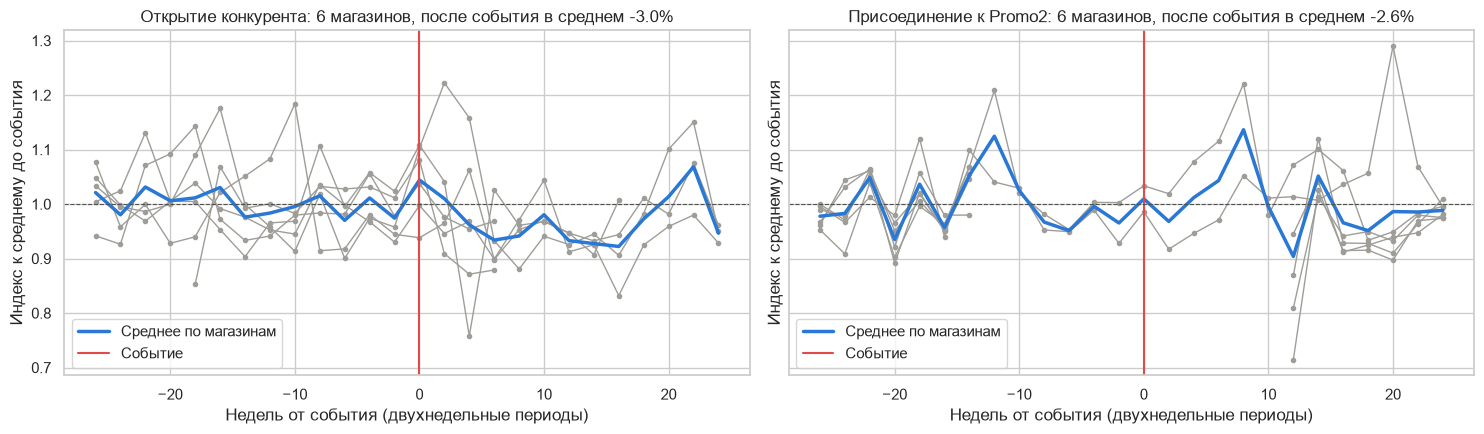

In [24]:
EVENT_WINDOW = 26   # недель до и после события

competitor_date = pd.to_datetime(
    store_subset[["CompetitionOpenSinceYear", "CompetitionOpenSinceMonth"]]
    .rename(columns={"CompetitionOpenSinceYear": "year", "CompetitionOpenSinceMonth": "month"}).assign(day=1),
    errors="coerce").set_axis(store_subset["Store"])
promo2_rows = store_subset.dropna(subset=["Promo2SinceYear", "Promo2SinceWeek"])
promo2_date = pd.Series(
    pd.to_datetime(promo2_rows["Promo2SinceYear"].astype(int).astype(str) + "-W"
                   + promo2_rows["Promo2SinceWeek"].astype(int).astype(str).str.zfill(2) + "-1", format="%G-W%V-%u").to_numpy(),
    index=promo2_rows["Store"])


def event_study(event_dates: pd.Series, weekly: pd.Series, window: int = EVENT_WINDOW) -> pd.DataFrame:
    '''Индекс магазинов по двухнедельным периодам относительно события, нормированный на среднее до события.
    Строки - магазины, столбцы - номер недели начала периода, NaN - нет данных.'''
    frame = weekly.rename("index").reset_index()
    frame = frame[frame["Store"].isin(event_dates.index)]
    frame["week"] = (frame["Date"] - frame["Store"].map(event_dates)).dt.days // 7
    frame = frame[frame["week"].between(-window, window - 1)]
    frame["period"] = frame["week"] // 2 * 2
    frame = frame.groupby(["Store", "period"], as_index=False)["index"].mean()
    before = frame[frame["period"] < 0].groupby("Store")["index"].mean()
    frame["relative"] = frame["index"] / frame["Store"].map(before)
    return frame.pivot(index="Store", columns="period", values="relative").reindex(columns=range(-window, window, 2))


in_train = lambda dates: dates[(dates > train_part["Date"].min() + pd.Timedelta(weeks=EVENT_WINDOW)) & (dates <= TRAIN_END)]
events = {"Открытие конкурента": in_train(competitor_date.dropna()),
          "Присоединение к Promo2": in_train(promo2_date)}

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), sharey=True)
for ax, (title, dates) in zip(axes, events.items()):
    study = event_study(dates, weekly_index)
    print(f"{title}: даты событий по магазинам {dates.dt.date.astype(str).to_dict()}")
    for store, row in study.iterrows():   # цикл по магазинам (их 6), а не по строкам данных
        ax.plot(row.index, row, color="#9e9d98", linewidth=1, marker=".")
    mean_curve = study.mean()
    ax.plot(mean_curve.index, mean_curve, color="#2a78d6", linewidth=2.5, label="Среднее по магазинам")
    ax.axvline(0, color="#e34948", linewidth=1.5, label="Событие")
    ax.axhline(1, color="#52514e", linestyle="--", linewidth=0.8)
    after = study.loc[:, study.columns >= 0].mean(axis=1)
    ax.set(title=f"{title}: {len(study)} магазинов, после события в среднем {after.mean() - 1:+.1%}",
           xlabel="Недель от события (двухнедельные периоды)", ylabel="Индекс к среднему до события")
    ax.legend(loc="lower left")
    print(f"{title}: изменение уровня по магазинам {(after - 1).round(3).to_dict()}")
flagged = selected.index[selected["competitor_opened_in_train"]]
print(f"Конкурент открылся в трейне, но до события меньше полугода данных: "
      f"{sorted(set(flagged) - set(events['Открытие конкурента'].index))}")
plt.tight_layout()
plt.show()

После открытия конкурента средний уровень спроса снизился на 3,0%. У 5 из 6 магазинов поток после открытия (события) оказался ниже, чем до него; изменения по магазинам составили от +1,5% до -6,5%. Всего в тренировочной выборке было 8 магазинов, у которых конкурент открылся в этот период, но для сравнения до и после события удалось использовать только 6. У магазинов 801 и 954 конкурент открылся в первые полгода наблюдений, поэтому данных до события недостаточно. Еще у трех магазинов - 103, 301 и 902 - открытие произошло весной 2015 года, поэтому после события прошло меньше полугода.

Подключение к Promo2 связано со средним снижением спроса на 2,6%, но результаты сильно различаются между магазинами: у 4 спрос снизился, а у 2 вырос. Изменения находятся в диапазоне от -8,4% до +4,2%. При этом эту оценку нельзя считать надежной. Четыре из шести магазинов подключились к Promo2 в один день - 29 сентября 2014 года, и у всех четырех есть пробелы в выгрузке. Поэтому большая часть периода после подключения приходится на отсутствующие данные. Фактически для них сравниваются апрель-июнь 2014 года и январь-март 2015 года, то есть разные сезоны. Январь и февраль относятся к сезонно слабым месяцам, поэтому снижение на 4-8% может объясняться сезонностью, а не подключением к Promo2.

**Ограничения анализа.** Событий мало, дата открытия конкурента известна только с точностью до месяца, а периоды до и после событий часто относятся к разным сезонам. Поэтому влияние самого события нельзя надежно отделить от сезонных изменений.

**Для модели:** наблюдаемые изменения уровня после событий относительно небольшие - несколько процентов - и сопоставимы с обычными колебаниями спроса. Признаки, основанные на недавней истории магазина, должны постепенно учитывать новый уровень спроса в течение нескольких недель. Признаки "конкурент открылся" и "участвует в Promo2" можно дополнительно проверить в модели, но по результатам этого анализа они не выглядят приоритетными.

## 5. Годовая сезонность

### 5.1 Профиль по месяцам

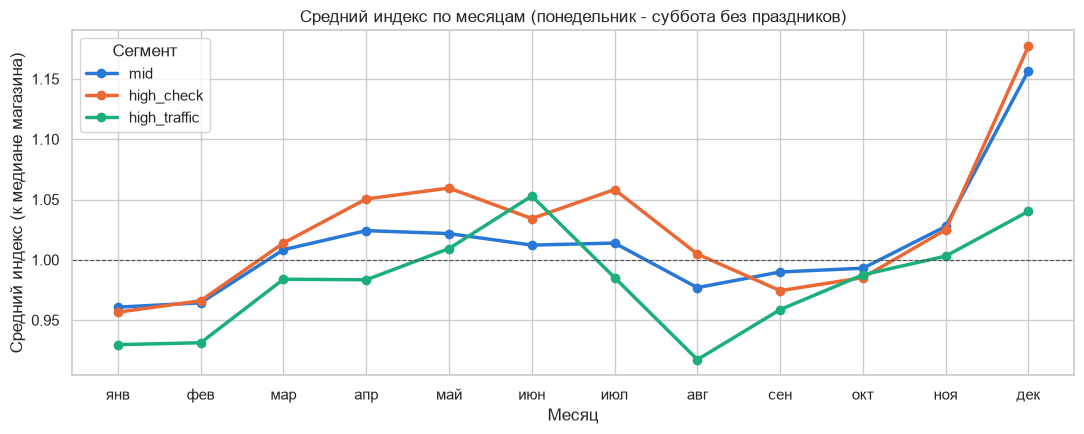

month,1,2,3,4,5,6,7,8,9,10,11,12
segment,,,,,,,,,,,,
high_check,0.957,0.966,1.014,1.050,1.059,1.034,1.058,1.005,0.974,0.985,1.025,1.177
high_traffic,0.930,0.931,0.984,0.983,1.009,1.053,0.985,0.917,0.959,0.988,1.003,1.040
mid,0.961,0.964,1.008,1.024,1.022,1.012,1.014,0.977,0.990,0.993,1.028,1.157


In [25]:
month_profile = (regular_days.assign(month=regular_days["Date"].dt.month)
                 .groupby(["segment", "Store", "month"])["index"].mean()
                 .groupby(["segment", "month"]).mean().unstack(0))

fig, ax = plt.subplots(figsize=(11, 4.5))
for segment, color in SEGMENT_COLORS.items():
    ax.plot(month_profile.index, month_profile[segment], color=color, linewidth=2.5, marker="o", label=segment)
ax.axhline(1, color="#52514e", linestyle="--", linewidth=0.8)
ax.set_xticks(range(1, 13), ["янв", "фев", "мар", "апр", "май", "июн", "июл", "авг", "сен", "окт", "ноя", "дек"])
ax.set(title="Средний индекс по месяцам (понедельник - суббота без праздников)", xlabel="Месяц",
       ylabel="Средний индекс (к медиане магазина)")
ax.legend(title="Сегмент")
plt.tight_layout()
plt.show()

month_profile.round(3).T

Годовая сезонность у сегментов `mid` и `high_check` почти одинаковая: минимум в январе - феврале (0.96), небольшой подъем весной и в начале лета (1.01-1.06), спад в августе - октябре и резкий пик в декабре (1.16-1.18). У `high_traffic` профиль другой: декабрьский пик слабый (1.04), максимум в июне (1.05), а провал в августе глубже (0.92). Вне декабря сезонные колебания у `mid` и `high_check` невелики - в пределах +-5%, у `high_traffic` - до -8% (август, январь).

**Для модели:** годовая сезонность - это прежде всего декабрь. Признаков месяца (или дней до Рождества) достаточно, а профиль сегмента `high_traffic` отличается, поэтому нужен признак сегмента или взаимодействие "месяц x сегмент".

### 5.2 Профиль по неделям года: повторяется ли он

Если профили разных лет совпадают, годовую сезонность можно выучить по истории. Магазины с пробелом выгрузки не участвуют в неделях второго полугодия 2014 года, но благодаря индексу это не сдвигает уровень.

Недельные значения сильно зависят от того, была ли в неделе промоакция (раздел 3.2), а чередование наличия/отсутствия промоакции в разные годы может приходиться на разные недели. Поэтому профиль показан дважды: в исходном индексе и в индексе, очищенном от эффекта промоакции (в дни промоакции индекс делится на средний эффект промоакции этого магазина).

Недель, в которые наличие промоакции в 2013 и 2014 годах совпадает: 60%


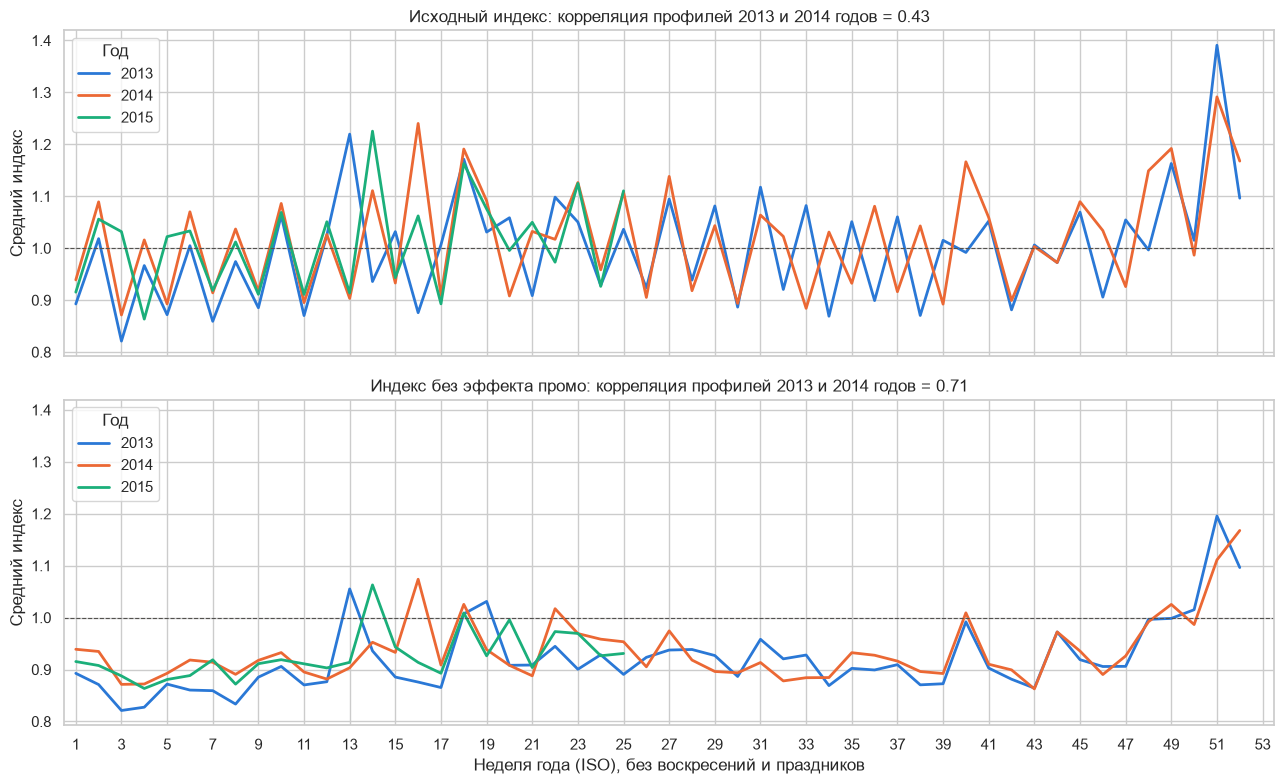

In [26]:
iso = regular_days["Date"].dt.isocalendar()
weeks = regular_days.assign(iso_year=iso["year"].to_numpy(), iso_week=iso["week"].to_numpy())

# Эффект промоакции каждого магазина (понедельник - пятница) и индекс, очищенный от этого эффекта
store_promo_effect = (weeks[weeks["DayOfWeek"].le(5)].groupby(["Store", "Promo"])["index"].mean()
                      .unstack().pipe(lambda d: d[1] / d[0]))
is_promo = weeks["Promo"].eq(1).fillna(False).to_numpy(dtype=bool)
weeks["index_no_promo"] = weeks["index"] / np.where(is_promo, weeks["Store"].map(store_promo_effect), 1.0)

promo_weeks = weeks.groupby(["iso_year", "iso_week"])["Promo"].mean().astype(float).round().unstack(0)
print(f"Недель, в которые наличие промоакции в 2013 и 2014 годах совпадает: {(promo_weeks[2013] == promo_weeks[2014]).mean():.0%}")

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True, sharey=True)
for ax, (column, title) in zip(axes, [("index", "Исходный индекс"), ("index_no_promo", "Индекс без эффекта промо")]):
    week_profile = weeks.groupby(["iso_year", "iso_week"])[column].mean().unstack(0)
    for year, color in zip(week_profile.columns, ["#2a78d6", "#eb6834", "#1baf7a"]):
        ax.plot(week_profile.index, week_profile[year], color=color, linewidth=2, label=str(year))
    common = week_profile[[2013, 2014]].dropna()
    ax.axhline(1, color="#52514e", linestyle="--", linewidth=0.8)
    ax.set(title=f"{title}: корреляция профилей 2013 и 2014 годов = {common[2013].corr(common[2014]):.2f}",
           ylabel="Средний индекс")
    ax.legend(title="Год", loc="upper left")
axes[1].set_xlabel("Неделя года (ISO), без воскресений и праздников")
axes[1].set_xticks(range(1, 54, 2))
axes[1].set_xticks(range(1, 54), minor=True)
axes[1].tick_params(axis="x", which="minor", length=3)
axes[1].set_xlim(0.5, 53.5)
plt.tight_layout()
plt.show()

В исходном индексе профили 2013 и 2014 годов по неделям совпадают слабо (корреляция 0.43): наличие промоакций в одни и те же недели двух лет совпадает только в 60% случаев, и "пила" промо в разные годы идет в разной фазе. После очистки от эффекта промоакции корреляция вырастает до 0.71. Очищенный профиль ровный большую часть года, с пиками в пасхальные недели (13-16, в разные годы на разных неделях), в неделе 18 (начало мая - предположительно из-за подготовки к Дню матери) и неделе 40 (начало октября - предположительно подготовка к Хэллоуину) и с ростом в декабре (недели 48-52).

**Для модели:** годовая сезонность повторяется, но номер недели не всегда точно описывает ее, потому что промоакции и некоторые праздники смещаются по календарю. Поэтому надежнее использовать несколько признаков: месяц, расстояние до праздников и факт проведения промоакции. По той же причине лаг 364 дня может быть не самым надежным признаком: значение за ту же дату прошлого года может относиться к другой фазе промоакции. В 40% недель промоакция в прошлом году не совпадает с текущей, поэтому такой лаг может переносить в модель нерелевантную информацию.

### 5.3 Плавающие праздники: Пасха

Пасха каждый год приходится на разные даты, поэтому в профиле по неделям года ее эффект размазывается по разным неделям. Дату Пасхи берем из данных: пасхальный понедельник - понедельник с праздником типа `b`, Пасха - на день раньше. Сравниваем поток вокруг Пасхи в календарных датах и в днях относительно Пасхи.

Пасха по данным: ['2013-03-31', '2014-04-20', '2015-04-05']


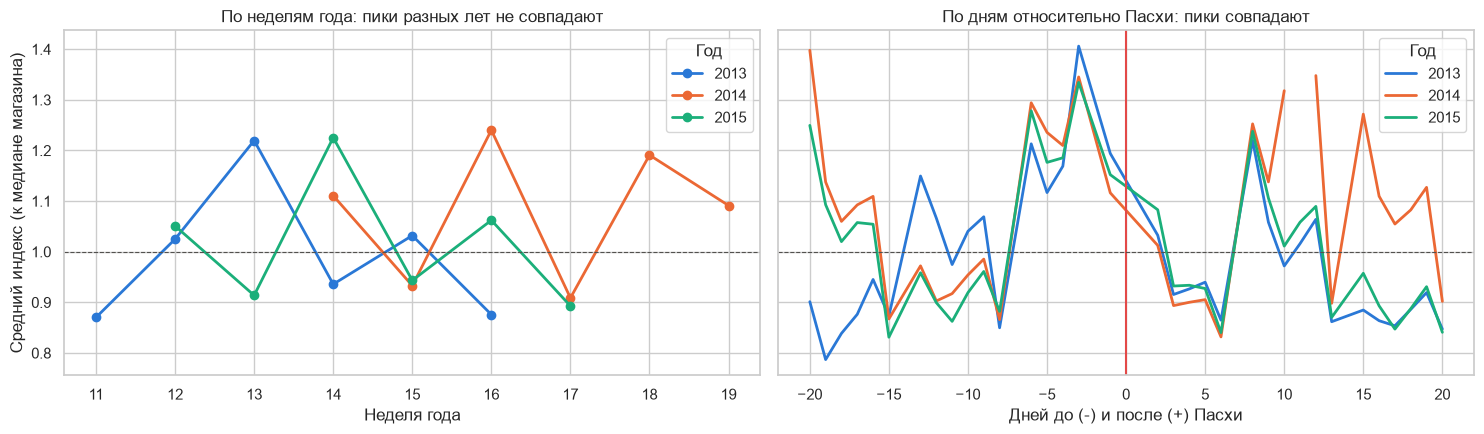

In [27]:
easter_mondays = calendar.loc[calendar["StateHoliday"].eq("b") & calendar["DayOfWeek"].eq(1), "Date"].unique()
easter = pd.Series(pd.to_datetime(easter_mondays) - pd.Timedelta(days=1)).sort_values()
print("Пасха по данным:", [d.date().isoformat() for d in easter])

EASTER_WINDOW = 21
around_easter = pd.concat([
    regular_days.assign(days_to_easter=(regular_days["Date"] - day).dt.days, year=day.year)
    .loc[lambda d: d["days_to_easter"].between(-EASTER_WINDOW, EASTER_WINDOW)]
    for day in easter
])
by_day = around_easter.groupby(["year", "days_to_easter"])["index"].mean().unstack(0)
by_week = (around_easter.assign(iso_week=around_easter["Date"].dt.isocalendar()["week"].to_numpy())
           .groupby(["year", "iso_week"])["index"].mean().unstack(0))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), sharey=True)
colors = ["#2a78d6", "#eb6834", "#1baf7a"]
for (year, color) in zip(by_week.columns, colors):
    axes[0].plot(by_week.index, by_week[year], color=color, linewidth=2, marker="o", label=str(year))
    axes[1].plot(by_day.index, by_day[year], color=color, linewidth=2, label=str(year))
axes[0].set(title="По неделям года: пики разных лет не совпадают", xlabel="Неделя года",
            ylabel="Средний индекс (к медиане магазина)")
axes[1].axvline(0, color="#e34948", linewidth=1.5)
axes[1].set(title="По дням относительно Пасхи: пики совпадают", xlabel="Дней до (-) и после (+) Пасхи")
for ax in axes:
    ax.axhline(1, color="#52514e", linestyle="--", linewidth=0.8)
    ax.legend(title="Год")
plt.tight_layout()
plt.show()

Даты Пасхи, восстановленные по данным, - 31 марта 2013 года, 20 апреля 2014 года и 5 апреля 2015 года. По неделям года пасхальные пики разных лет приходятся на разные недели, а в днях относительно Пасхи совпадают: максимум за 3 дня до Пасхи (четверг перед Страстной пятницей, индекс 1.33-1.41) и второй пик в понедельник Страстной недели (за 6 дней, около 1.2-1.3). После Пасхи устойчивого эффекта нет: колебания задает промоакция.

**Для модели:** пасхальный эффект нужно привязывать к дате Пасхи - признаком "дней до Пасхи" или "предпраздничный день", а не номером недели.

## 6. Праздники

### 6.1 Поток вокруг государственных праздников

Для каждого магазина находим праздничные периоды (подряд идущие праздничные дни) и смотрим 7 дней до и после начала периода: средний индекс в открытые дни и долю открытых магазинов. Для Пасхи точка отсчета - Страстная пятница. Воскресенья исключены: большинство магазинов закрыто по воскресеньям независимо от праздников, а воскресенье попадает на разные дни относительно праздника. Магазины `high_traffic` работают и в праздники, поэтому в расчете среднего индекса они не участвуют (иначе в праздничные дни среднее считалось бы только по ним), их поведение в праздники выводится отдельно.

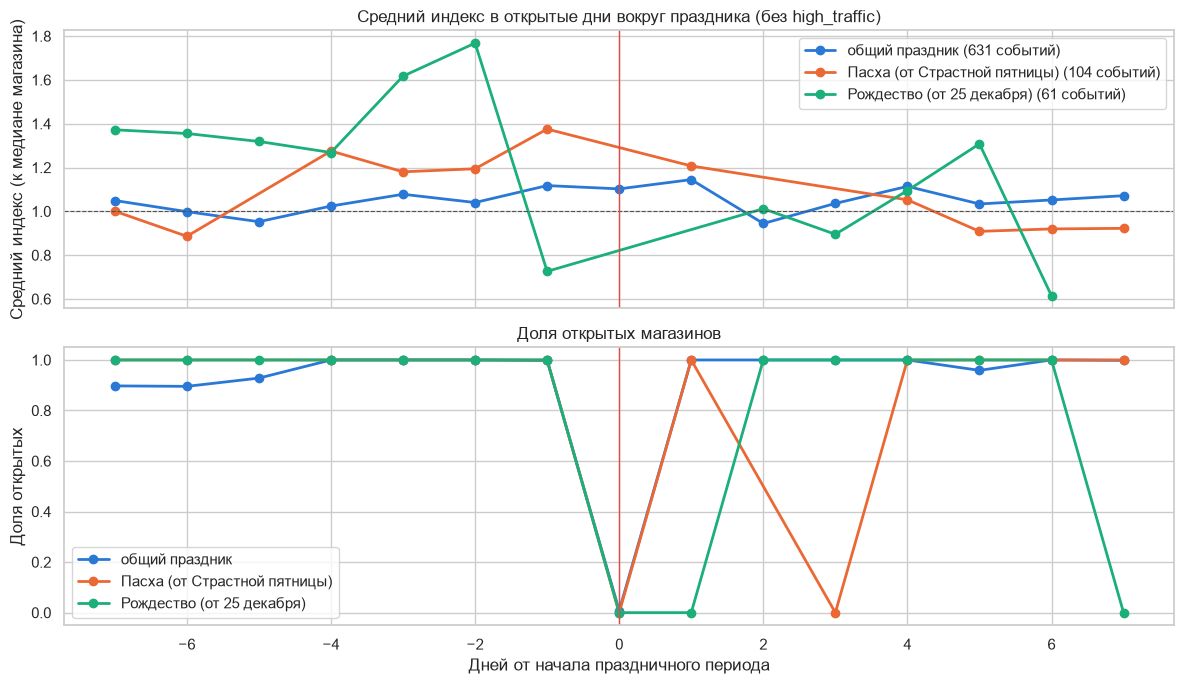

high_traffic в первый день праздника: открыто 100%, средний индекс 0.97


In [28]:
HOLIDAY_NAMES = {"a": "общий праздник", "b": "Пасха (от Страстной пятницы)", "c": "Рождество (от 25 декабря)"}
HOLIDAY_WINDOW = 7

holidays = (calendar.loc[calendar["StateHoliday"].isin(list(HOLIDAY_NAMES)), ["Store", "Date", "StateHoliday"]]
            .sort_values(["Store", "Date"]))
block_start = holidays.groupby("Store")["Date"].diff().ne(pd.Timedelta(days=1))
holiday_starts = holidays[block_start]
# Пасха: точка отсчета - Страстная пятница, пасхальный понедельник отдельным событием не считаем
holiday_starts = (holiday_starts[holiday_starts["StateHoliday"].ne("b") | holiday_starts["Date"].dt.dayofweek.eq(4)]
                  .rename(columns={"Date": "holiday_start", "StateHoliday": "holiday_type"}))

holiday_window = (holiday_starts.merge(pd.DataFrame({"rel_day": range(-HOLIDAY_WINDOW, HOLIDAY_WINDOW + 1)}), how="cross")
                  .assign(Date=lambda d: d["holiday_start"] + pd.to_timedelta(d["rel_day"], unit="D"))
                  .merge(calendar[["Store", "Date", "day_status", "index"]], on=["Store", "Date"])
                  .join(selected["segment"], on="Store"))
holiday_window = holiday_window[holiday_window["day_status"].isin(["open", "closed"])
                                & holiday_window["Date"].dt.dayofweek.ne(6)]
not_ht = holiday_window[holiday_window["segment"] != "high_traffic"]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for (holiday_type, name), color in zip(HOLIDAY_NAMES.items(), ["#2a78d6", "#eb6834", "#1baf7a"]):
    part = not_ht[not_ht["holiday_type"] == holiday_type]
    n_events = part[["Store", "holiday_start"]].drop_duplicates().shape[0]
    mean_index = part[part["day_status"] == "open"].groupby("rel_day")["index"].mean().astype(float)
    share_open = part.groupby("rel_day")["day_status"].apply(lambda s: s.eq("open").mean())
    axes[0].plot(mean_index.index, mean_index, color=color, linewidth=2, marker="o", label=f"{name} ({n_events} событий)")
    axes[1].plot(share_open.index, share_open, color=color, linewidth=2, marker="o", label=name)
axes[0].axhline(1, color="#52514e", linestyle="--", linewidth=0.8)
axes[0].set(title="Средний индекс в открытые дни вокруг праздника (без high_traffic)",
            ylabel="Средний индекс (к медиане магазина)")
axes[1].set(title="Доля открытых магазинов", xlabel="Дней от начала праздничного периода", ylabel="Доля открытых")
for ax in axes:
    ax.axvline(0, color="#e34948", linewidth=1)
    ax.legend()
plt.tight_layout()
plt.show()

ht_holidays = holiday_window[(holiday_window["segment"] == "high_traffic") & holiday_window["rel_day"].eq(0)]
print(f"high_traffic в первый день праздника: открыто {ht_holidays['day_status'].eq('open').mean():.0%}, "
      f"средний индекс {ht_holidays['index'].astype(float).mean():.2f}")

В сам праздник магазины (кроме `high_traffic`) закрыты. Вокруг праздника поведение зависит от его типа:
- **общий праздник:** в день до и после праздника поток выше обычного (1.12 и 1.15) - покупки переносятся на соседние дни;
- **Пасха:** поток растет всю неделю перед Страстной пятницей до пика в четверг (1.38), в субботу между праздниками поток тоже высокий (1.21), в пасхальный понедельник магазины закрыты;
- **Рождество:** за 2-4 дня до 25 декабря поток на 27-77% выше обычного, а 24 декабря - наоборот, заметно ниже (0.73), 25-26 декабря магазины закрыты.

Магазины `high_traffic` в праздники открыты (100%) с почти обычным потоком (индекс 0.97).

**Для модели:** закрытие в праздник известно заранее (расписание), и прогноз в такой день - 0 по правилу. Для спроса важны не сами праздники, а дни вокруг них: нужны признаки "дней до ближайшего праздника" и "дней после праздника" с учетом типа праздника, а для `high_traffic` праздник - почти обычный день.

### 6.2 Рождественский период подробно

Период с 15 декабря по 6 января для двух сезонов, воскресенья исключены (дни недели у сезонов разные).

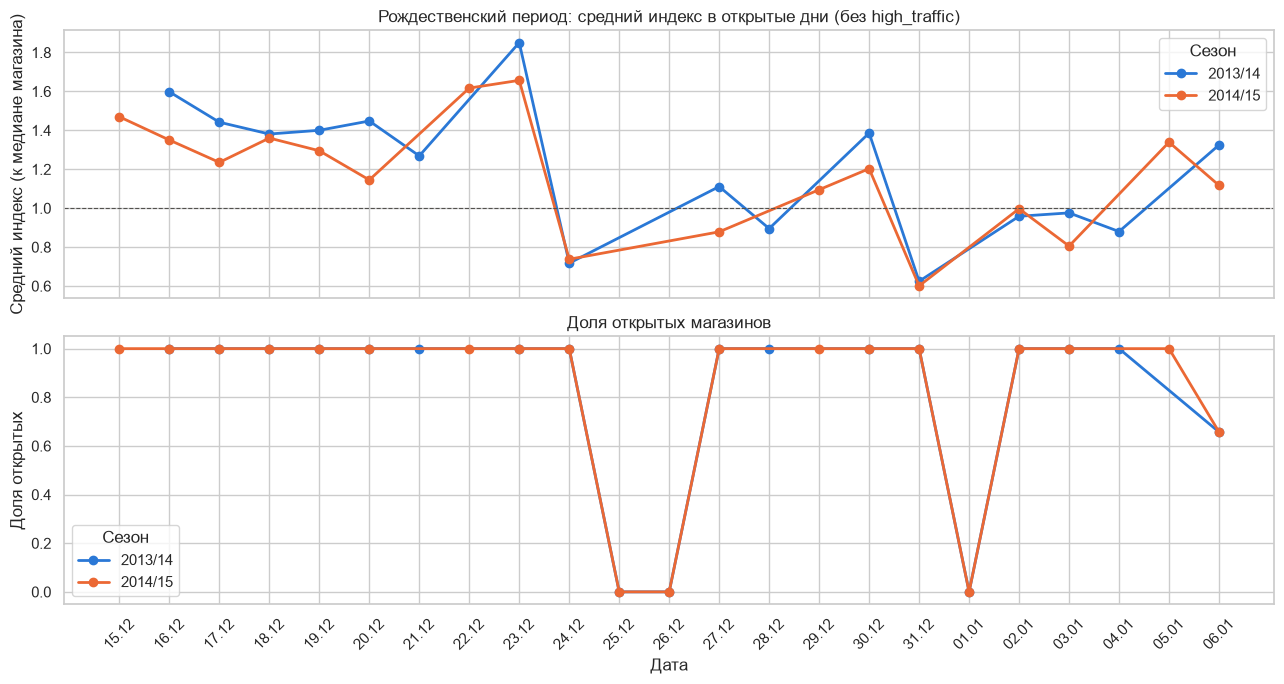

In [29]:
seasons = {"2013/14": ("2013-12-15", "2014-01-06"), "2014/15": ("2014-12-15", "2015-01-06")}
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for (season, (start, end)), color in zip(seasons.items(), ["#2a78d6", "#eb6834"]):
    period = calendar[calendar["Date"].between(start, end) & calendar["day_status"].isin(["open", "closed"])]
    period = period.join(selected["segment"], on="Store")
    period = period[(period["segment"] != "high_traffic") & period["Date"].dt.dayofweek.ne(6)]
    days = (period["Date"] - pd.Timestamp(start)).dt.days
    mean_index = period[period["day_status"] == "open"].groupby(days)["index"].mean().astype(float)
    share_open = period.groupby(days)["day_status"].apply(lambda s: s.eq("open").mean())
    axes[0].plot(mean_index.index, mean_index, color=color, linewidth=2, marker="o", label=season)
    axes[1].plot(share_open.index, share_open, color=color, linewidth=2, marker="o", label=season)
labels = pd.date_range("2013-12-15", "2014-01-06").strftime("%d.%m")
axes[1].set_xticks(range(len(labels)), labels, rotation=45)
axes[0].axhline(1, color="#52514e", linestyle="--", linewidth=0.8)
axes[0].set(title="Рождественский период: средний индекс в открытые дни (без high_traffic)",
            ylabel="Средний индекс (к медиане магазина)")
axes[1].set(title="Доля открытых магазинов", xlabel="Дата", ylabel="Доля открытых")
for ax in axes:
    ax.legend(title="Сезон")
plt.tight_layout()
plt.show()

Рождественский период в двух сезонах почти одинаков:
- с середины декабря поток на 15-60% выше обычного, пик - 23 декабря (1.66-1.85);
- 24 и 31 декабря поток резко падает (0.6-0.75) - это подтверждает гипотезу из ноутбука 01 о сокращенных предпраздничных днях;
- 25-26 декабря и 1 января магазины закрыты;
- между праздниками поток неровный, с подъемом 30 декабря (1.2-1.38);
- 2-4 января поток ниже обычного, 6 января (региональный праздник) закрыта примерно треть магазинов.

**Для модели:** рождественский период - самый предсказуемый по календарю и самый нетипичный по уровню. Нужны признаки конкретных дней (или "дней до Рождества" и "дней до Нового года"), а при поиске выбросов эти дни нельзя считать выбросами - это события.

### 6.3 Школьные каникулы

Каникулы приходятся на определенные периоды (лето, Пасха, осень, Рождество), поэтому простое сравнение "каникулы / не каникулы" смешало бы эффект каникул с сезонностью. Сравниваем внутри одного магазина и одного месяца: средний индекс в дни каникул к среднему в остальные дни того же месяца.

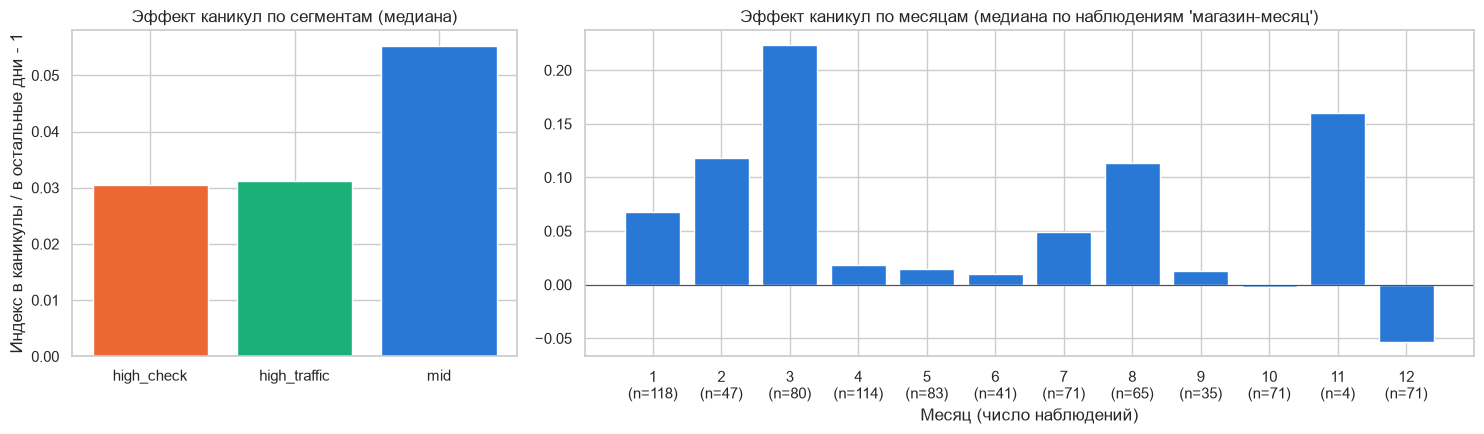

Эффект каникул по всем наблюдениям 'магазин-месяц': медиана +4.4%


In [30]:
school = (regular_days.assign(month=regular_days["Date"].dt.to_period("M"))
          .groupby(["segment", "Store", "month", "SchoolHoliday"])["index"].mean().unstack("SchoolHoliday")
          .dropna())
school_effect = (school[1] / school[0] - 1).rename("effect").reset_index()
school_effect["month_num"] = school_effect["month"].dt.month

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [1, 2]})
by_segment = school_effect.groupby("segment")["effect"].median()
axes[0].bar(by_segment.index, by_segment, color=[SEGMENT_COLORS[s] for s in by_segment.index])
axes[0].axhline(0, color="#52514e", linewidth=0.8)
axes[0].set(title="Эффект каникул по сегментам (медиана)", ylabel="Индекс в каникулы / в остальные дни - 1")
by_month = school_effect.groupby("month_num")["effect"].agg(["median", "size"])
axes[1].bar(by_month.index, by_month["median"], color="#2a78d6")
axes[1].axhline(0, color="#52514e", linewidth=0.8)
axes[1].set_xticks(by_month.index, [f"{m}\n(n={n})" for m, n in zip(by_month.index, by_month["size"])])
axes[1].set(title="Эффект каникул по месяцам (медиана по наблюдениям 'магазин-месяц')", xlabel="Месяц (число наблюдений)")
plt.tight_layout()
plt.show()

print(f"Эффект каникул по всем наблюдениям 'магазин-месяц': медиана {school_effect['effect'].median():+.1%}")

В дни школьных каникул поток в среднем немного выше, чем в остальные дни того же месяца (медиана +4.4%), сильнее в сегменте `mid` (+5.5%), чем в двух других сегментах (около +3%). По месяцам эффект неоднороден: наибольший в марте (+22%), феврале (+12%) и августе (+11%), около нуля в апреле - июне и сентябре - октябре, отрицательный в декабре (-5%). Значение для ноября (+16%) опирается всего на 4 наблюдения "магазин-месяц". Эффект марта, скорее всего, частично связан с Пасхой: пасхальные каникулы совпадают с предпасхальным ростом потока (раздел 5.3).

**Для модели:** признак школьных каникул полезен, но его эффект умеренный и пересекается с праздниками. Отдельно от признаков "дней до праздника" его вклад оценить нельзя - модель должна получать их вместе.

### 6.4 Полнота флага праздника

Если в какой-то будний день закрыта заметная доля магазинов, но праздник у них не отмечен, флаг `StateHoliday` неполон и как признак ему нельзя полностью доверять. Считаем по дням долю магазинов, закрытых в понедельник - субботу без флага праздника (без `high_traffic`, только известные дни).

In [31]:
known_days = (calendar[calendar["day_status"].isin(["open", "closed"]) & calendar["DayOfWeek"].le(6)]
              .join(selected["segment"], on="Store"))
known_days = known_days[known_days["segment"] != "high_traffic"]
unflagged_closed = (known_days.assign(unflagged=known_days["day_status"].eq("closed") & known_days["StateHoliday"].eq("0"))
                    .groupby("Date")["unflagged"].agg(share="mean", stores="sum"))

print("Распределение доли магазинов, закрытых без флага праздника:")
print(unflagged_closed["share"].describe(percentiles=[0.5, 0.9, 0.99]).round(3).to_string())
unflagged_closed[unflagged_closed["stores"] > 0].sort_values("share", ascending=False).head(12).assign(
    day=lambda d: d.index.day_name()).round(3)

Распределение доли магазинов, закрытых без флага праздника:
count    772.000
mean       0.001
std        0.008
min        0.000
50%        0.000
90%        0.000
99%        0.000
max        0.118


,share,stores,day
Date,,,
2013-02-11,0.118,4,Monday
2014-03-03,0.114,4,Monday
2015-02-16,0.114,4,Monday
2015-01-01,0.086,3,Thursday
2013-04-30,0.029,1,Tuesday
2013-06-06,0.029,1,Thursday


Флаг праздника присутствует почти во всех случаях: в 99% дней нет ни одного магазина, закрытого в будний день без флага. Исключения:
- понедельники 11 февраля 2013 года, 3 марта 2014 года и 16 февраля 2015 года - это карнавальный понедельник (региональный, а не государственный праздник): закрыто около 11% магазинов;
- 1 января 2015 года 3 магазина закрыты, но праздник у них не отмечен - пропуск во флаге.

**Для модели:** `StateHoliday` можно использовать как признак, но закрытие магазина определяется расписанием (`Open`), а не флагом. Карнавальный понедельник - региональное событие, в флаге его нет; при необходимости его можно добавить в календарь праздников отдельно.

## 7. Выбросы

### 7.1 Метод поиска

Выброс - это день, в который число покупателей заметно отличается от обычного уровня для похожих дней этого же магазина. Чтобы сравнение было корректным, за "похожие дни" считаем дни с тем же днем недели и той же фазой промоакции. Это позволяет не принимать обычные различия между буднями и выходными или влияние промоакций за выбросы. Эталон для дня - медиана числа покупателей в 5 ближайших похожих днях (2 до, сам день и 2 после). Медиана используется потому, что она мало чувствительна к самому выбросу: даже если один из дней сильно отличается, он не сильно меняет эталон. 

Отклонение считается в логарифме: log(покупатели / эталон), так что +0.4 и -0.4 - одинаково сильные отклонения вверх и вниз (примерно в 1.5 раза).

У магазинов разный уровень обычного шума (раздел 2.2), поэтому отклонение нормируется на робастный разброс магазина: $$
z = \frac{d - \operatorname{median}(d)}
{1.4826 \times MAD(d)}
$$

Здесь MAD - медианное абсолютное отклонение от медианы. Множитель 1.4826 приводит MAD к масштабу стандартного отклонения при нормальном распределении.

Таким образом, итоговый показатель показывает, насколько необычным является отклонение относительно обычных колебаний конкретного магазина. В расчет включаются только дни, когда магазин был открыт.

Робастный разброс отклонения по магазинам (в логарифме): от 0.039 до 0.073


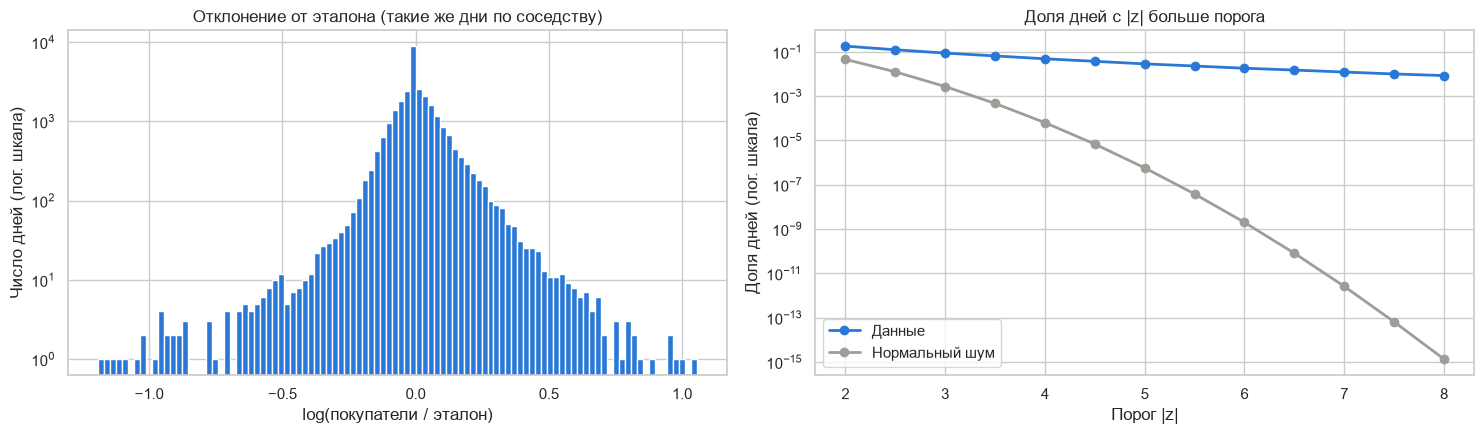

In [32]:
REF_NEIGHBOURS = 2

deviation = open_calendar[["Store", "Date", "DayOfWeek", "Promo", "StateHoliday", "customers_clean", "index"]].copy()
deviation["customers"] = deviation["customers_clean"].astype(float)
deviation = deviation.sort_values("Date")
deviation["reference"] = (deviation.groupby(["Store", "DayOfWeek", "Promo"])["customers"]
                          .transform(lambda s: s.rolling(2 * REF_NEIGHBOURS + 1, center=True, min_periods=3).median()))
deviation["log_ratio"] = np.log(deviation["customers"] / deviation["reference"])

by_store = deviation.groupby("Store")["log_ratio"]
store_center = by_store.transform("median")
store_scale = 1.4826 * (deviation["log_ratio"] - store_center).abs().groupby(deviation["Store"]).transform("median")
deviation["z"] = (deviation["log_ratio"] - store_center) / store_scale

print(f"Робастный разброс отклонения по магазинам (в логарифме): "
      f"от {store_scale.groupby(deviation['Store']).first().min():.3f} до {store_scale.groupby(deviation['Store']).first().max():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].hist(deviation["log_ratio"].dropna(), bins=100, color="#2a78d6")
axes[0].set_yscale("log")
axes[0].set(title="Отклонение от эталона (такие же дни по соседству)",
            xlabel="log(покупатели / эталон)", ylabel="Число дней (лог. шкала)")

thresholds = np.arange(2, 8.5, 0.5)
share_flagged = [(deviation["z"].abs() > t).mean() for t in thresholds]
share_normal = [2 * (1 - norm.cdf(t)) for t in thresholds]
axes[1].plot(thresholds, share_flagged, color="#2a78d6", marker="o", linewidth=2, label="Данные")
axes[1].plot(thresholds, share_normal, color="#9e9d98", marker="o", linewidth=2, label="Нормальный шум")
axes[1].set_yscale("log")
axes[1].set(title="Доля дней с |z| больше порога", xlabel="Порог |z|", ylabel="Доля дней (лог. шкала)")
axes[1].legend()
plt.tight_layout()
plt.show()

Отклонения от эталона в основном небольшие: центральная часть распределения узкая, а робастный разброс у магазинов - от 0.039 до 0.073 в логарифме, то есть обычный день отличается от таких же соседних дней примерно на 4-7%. Но хвосты очень тяжелые: на правом графике доля дней с большим |z| убывает с ростом порога гораздо медленнее, чем при нормальном шуме. При нормальном шуме |z| > 5 встречалось бы примерно в 6 случаях на 10 миллионов дней, а в данных - почти в 3% дней. Значит, большие отклонения - не случайный шум, а отдельные события или ошибки.

Порог выбран строгим: |z| > 5. При нормальном шуме таких дней практически не было бы, поэтому каждый отмеченный день действительно необычен. Насколько выводы зависят от выбора порога, проверяется ниже.

In [33]:
Z_THRESHOLD = 5

deviation["is_outlier"] = deviation["z"].abs() > Z_THRESHOLD
deviation["direction"] = np.where(deviation["z"] > 0, "вверх", "вниз")
outliers = deviation[deviation["is_outlier"]]
print(f"Выбросов: {len(outliers)} ({deviation['is_outlier'].mean():.1%} открытых дней), "
      f"вверх {outliers['direction'].eq('вверх').sum()}, вниз {outliers['direction'].eq('вниз').sum()}, "
      f"магазинов с выбросами: {outliers['Store'].nunique()} из {deviation['Store'].nunique()}")
print(f"Порогу соответствует отклонение примерно в {np.exp(Z_THRESHOLD * store_scale.median()):.2f} раза "
      f"для магазина с медианным разбросом")

Выбросов: 814 (2.8% открытых дней), вверх 529, вниз 285, магазинов с выбросами: 40 из 40
Порогу соответствует отклонение примерно в 1.31 раза для магазина с медианным разбросом


### 7.2 Чем объясняются выбросы

Каждый выброс сопоставляем с событиями, найденными в предыдущих разделах, в таком порядке: рождественский период (15 декабря - 6 января, раздел 6.2), неделя перед Пасхой и пасхальные выходные (от 7 дней до Пасхи до следующего дня после нее, раздел 5.3), карнавал (от четверга до вторника вокруг карнавального понедельника; сами понедельники - дни, когда без флага праздника закрыто не менее 10% магазинов, раздел 6.4), 2 дня до и после государственного праздника (раздел 6.1), первые 2 недели после возвращения из длинного закрытия (раздел 1.4) и неделя перед длинным закрытием. Остальные выбросы - без объяснения.

In [34]:
previous_status = calendar.groupby("Store")["day_status"].shift()
absent_starts = (calendar.loc[calendar["day_status"].eq("absent") & previous_status.ne("absent"), ["Store", "Date"]]
                 .rename(columns={"Date": "absent_start"}).sort_values("absent_start"))
holiday_days = holiday_starts[["Store", "holiday_start"]].sort_values("holiday_start")
carnival_mondays = unflagged_closed.index[(unflagged_closed["share"] >= 0.1) & (unflagged_closed.index.dayofweek == 0)]
print("Карнавальные понедельники (раздел 6.4):", [d.date().isoformat() for d in carnival_mondays])
CAUSES = ["Рождественский период", "Пасха", "Карнавал", "Рядом с праздником", "После длинного закрытия",
          "Перед длинным закрытием"]


def explain_outliers(days: pd.DataFrame) -> pd.DataFrame:
    '''Добавляет к дням-выбросам причину: первое подходящее событие из CAUSES или "Без объяснения".'''
    frame = (days.sort_values("Date")
             .pipe(lambda d: pd.merge_asof(d, absent_starts, left_on="Date", right_on="absent_start",
                                           by="Store", direction="forward"))
             .pipe(lambda d: pd.merge_asof(d, holiday_days, left_on="Date", right_on="holiday_start",
                                           by="Store", direction="nearest"))
             .merge(calendar[["Store", "Date", "days_since_reopen"]], on=["Store", "Date"], how="left"))
    month_day = frame["Date"].dt.month * 100 + frame["Date"].dt.day
    near_easter = pd.concat([(frame["Date"] - day).dt.days.between(-7, 1) for day in easter], axis=1).any(axis=1)
    near_carnival = pd.concat([(frame["Date"] - day).dt.days.between(-4, 1) for day in carnival_mondays],
                              axis=1).any(axis=1)
    masks = [
        (month_day >= 1215) | (month_day <= 106),
        near_easter,
        near_carnival,
        (frame["Date"] - frame["holiday_start"]).dt.days.abs().le(2),
        frame["days_since_reopen"].between(0, 13),
        (frame["absent_start"] - frame["Date"]).dt.days.between(1, 7),
    ]
    frame["cause"] = np.select([m.fillna(False).to_numpy(dtype=bool) for m in masks], CAUSES, default="Без объяснения")
    return frame


context = explain_outliers(outliers[["Store", "Date", "direction", "z"]])
cause_table = pd.crosstab(context["cause"], context["direction"], margins=True, margins_name="всего")
cause_table["доля"] = (cause_table["всего"] / len(context)).round(3)
cause_table.sort_values("всего", ascending=False)

Карнавальные понедельники (раздел 6.4): ['2013-02-11', '2014-03-03', '2015-02-16']


direction,вверх,вниз,всего,доля
cause,,,,
всего,529,285,814,1.000
Рождественский период,186,107,293,0.360
Без объяснения,56,124,180,0.221
Рядом с праздником,154,19,173,0.213
Пасха,108,13,121,0.149
После длинного закрытия,25,0,25,0.031
Карнавал,0,18,18,0.022
Перед длинным закрытием,0,4,4,0.005


In [35]:
# Устойчивость к выбору порога: доля выбросов, объясненных событиями, при разных порогах
candidates_z = explain_outliers(deviation.loc[deviation["z"].abs() > 3, ["Store", "Date", "z"]])
sensitivity = pd.DataFrame(
    [(t, (candidates_z["z"].abs() > t).sum(),
      (candidates_z.loc[candidates_z["z"].abs() > t, "cause"] != "Без объяснения").mean())
     for t in [3, 3.5, 4, 5, 6, 8]],
    columns=["порог |z|", "выбросов", "доля объясненных событиями"])
sensitivity.round(3)

,порог |z|,выбросов,доля объясненных событиями
0,3.0,2501,0.598
1,3.5,1857,0.659
2,4.0,1382,0.713
3,5.0,814,0.779
4,6.0,517,0.822
5,8.0,241,0.867


При пороге |z| > 5 найдено 814 выбросов. Это 2,8% всех открытых дней, причем выбросы встречаются у всех 40 магазинов: 529 случаев связаны с необычно высоким спросом, 285 - с необычно низким. Для магазина с медианным уровнем обычных колебаний такой порог соответствует отклонению примерно в 1,3 раза от типичного уровня для похожих соседних дней. То есть выбросы - это не обязательно экстремальные значения сами по себе: они считаются необычными относительно обычной динамики конкретного магазина. 

Большинство выбросов объясняются событиями, найденными в предыдущих разделах:
- рождественский период - 36% всех выбросов, в эту группу входят как высокие предрождественские пики, так и резкое снижение спроса 24 и 31 декабря и в начале января;
- дни рядом с государственными праздниками - 21%, почти все направлены вверх: покупки переносятся на соседние дни;
- Пасха - 15%, почти все выбросы связаны с повышенным спросом;
- первые две недели после длинного закрытия - 3%, все направлены вверх (всплеск после открытия, раздела 1.4);
- карнавал - 2%, все такие выбросы связаны со снижением спроса;
- неделя перед длинным закрытием - 4 выброса, все со снижением спроса.

Без объяснения остаются 180 выбросов (22%). При этом примерно две трети из них связаны со снижением спроса, а не с его ростом.

Результат не сильно зависит от выбранного порога. При |z| > 3 известными событиями объясняется около 60% выбросов, при |z| > 5 - 78%, а при |z| > 8 - уже 87%. Это показывает, что чем сильнее отклонение от обычного уровня, тем чаще оно связано с известным календарным или бизнес-событием.

**Для модели:** большая часть выбросов - события календаря, а не ошибки. Удалять их нельзя: модель должна видеть праздничные и рождественские дни и получать для них признаки.

### 7.3 Проверка метода через STL-разложение

STL раскладывает ряд на тренд, сезонность и остаток; выбросы - дни с большим остатком. Если основной метод и STL в основном находят одни и те же дни, основной метод не является артефактом своей конструкции.

Проверка на трех магазинах без пропусков в данных и длинных закрытий - по одному типичному магазину каждого сегмента (рост ближе всего к медиане сегмента). Ряд - логарифм покупателей, очищенный от эффекта промоакции (как в разделе 5.2), с недельным периодом. Закрытые дни для разложения заполняются интерполяцией, но выбросы ищутся только среди открытых дней.

In [36]:
clean_stores = calendar.groupby("Store")["day_status"].apply(lambda s: not s.isin(["absent", "missing_export"]).any())
candidates = segment_growth[clean_stores.reindex(segment_growth.index)]
stl_stores = (candidates.assign(distance=lambda d: (d["growth"] - d.groupby("segment")["growth"].transform("median")).abs())
              .sort_values("distance").groupby("segment").head(1).index.tolist())
print("Магазины для проверки:", {s: selected.loc[s, "segment"] for s in stl_stores})

comparison = []
stl_results = {}
for store in stl_stores:
    store_days = calendar[calendar["Store"] == store].set_index("Date")
    is_open = store_days["day_status"].eq("open")
    promo_factor = np.where(store_days["Promo"].eq(1).fillna(False).to_numpy(dtype=bool), store_promo_effect[store], 1.0)
    series = np.log(store_days["customers_clean"].astype(float).where(is_open) / promo_factor).astype(float)
    fitted = STL(series.interpolate(limit_direction="both"), period=7, robust=True).fit()
    resid = fitted.resid[is_open]
    stl_z = (resid - resid.median()) / (1.4826 * (resid - resid.median()).abs().median())
    stl_flag = set(stl_z.index[stl_z.abs() > Z_THRESHOLD])
    main_flag = set(outliers.loc[outliers["Store"] == store, "Date"])
    stl_results[store] = (store_days, is_open, stl_flag, main_flag)
    comparison.append({"магазин": store, "сегмент": selected.loc[store, "segment"],
                       "основной метод": len(main_flag), "STL": len(stl_flag), "общих": len(main_flag & stl_flag),
                       "доля выбросов основного метода, найденных STL": len(main_flag & stl_flag) / max(len(main_flag), 1)})
pd.DataFrame(comparison).round(2)

Магазины для проверки: {75: 'high_check', 593: 'mid', 494: 'high_traffic'}


,магазин,сегмент,основной метод,STL,общих,"доля выбросов основного метода, найденных STL"
0,75,high_check,30,39,20,0.67
1,593,mid,30,54,22,0.73
2,494,high_traffic,34,73,29,0.85


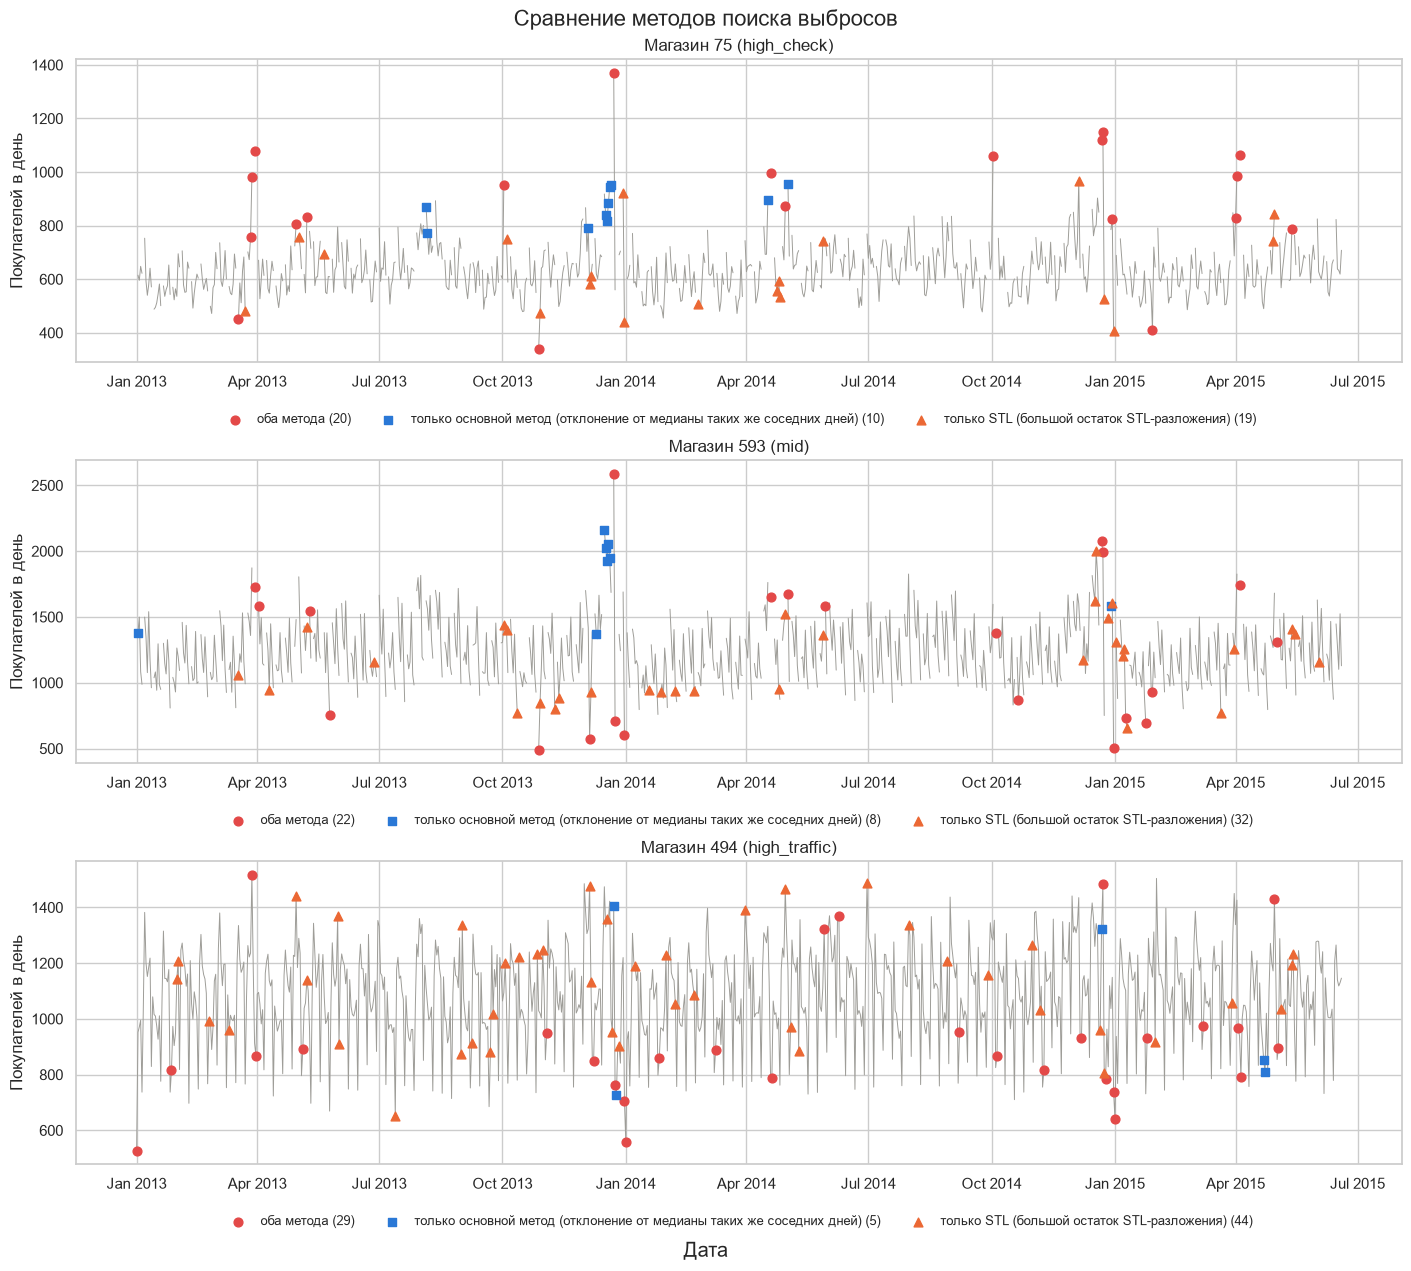

In [37]:
fig, axes = plt.subplots(len(stl_stores), 1, figsize=(14, 4.2 * len(stl_stores)), sharex=True, layout="constrained")
for ax, store in zip(np.atleast_1d(axes), stl_stores):
    store_days, is_open, stl_flag, main_flag = stl_results[store]
    daily = store_days["customers_clean"].astype(float).where(is_open)
    ax.plot(daily.index, daily, color="#9e9d98", linewidth=0.7)
    both, only_main, only_stl = main_flag & stl_flag, main_flag - stl_flag, stl_flag - main_flag
    for dates, color, marker, label in [(both, "#e34948", "o", "оба метода"),
                                        (only_main, "#2a78d6", "s", "только основной метод (отклонение от медианы таких же соседних дней)"),
                                        (only_stl, "#eb6834", "^", "только STL (большой остаток STL-разложения)")]:
        dates = sorted(dates)
        ax.scatter(dates, daily.loc[dates], color=color, marker=marker, s=40, zorder=3, label=f"{label} ({len(dates)})")
    ax.set(title=f"Магазин {store} ({selected.loc[store, 'segment']})", ylabel="Покупателей в день")
    ax.tick_params(axis="x", labelbottom=True)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=3, fontsize=9, frameon=False)
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 4, 7, 10)))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.suptitle("Сравнение методов поиска выбросов", fontsize=16)
fig.supxlabel("Дата")
plt.show()

STL в основном подтверждает результаты основного метода: среди дней, которые основной метод определяет как выбросы, STL также находит 67% у магазина 75, 73% у магазина 593 и 85% у магазина 494.

При этом STL отмечает больше дней в целом: от 39 до 73 против 30-34 у основного метода. Особенно заметна разница у магазина 494 (сегмент `high_traffic`), который работает без выходных. Для него недельная сезонность и усредненная поправка на промоакции, используемые в STL, хуже описывают обычные колебания спроса, поэтому часть нормальных изменений попадает в остаток и определяется как выброс.

Многие дни, которые находит только основной метод, приходятся на декабрь. Вероятно, STL частично воспринимает предрождественский рост как изменение тренда, тогда как основной метод сравнивает каждый день с ближайшими днями того же типа и поэтому лучше учитывает локальное изменение спроса.

**Для модели:** оба независимых метода находят в основном одни и те же необычные дни. Это подтверждает, что результаты основного метода не являются просто следствием его способа построения. Для дальнейшей работы используем основной метод: он учитывает фазу промоакции и проще интерпретируется.

### 7.4 Выбросы без объяснения подробно

Выбросы, которые не объясняются найденными событиями, - кандидаты в ошибки данных или в события, которых нет в календаре. Смотрим на них подробнее: когда они происходят и в какую сторону.

In [38]:
unexplained = context[context["cause"] == "Без объяснения"].copy()
unexplained["weekday"] = unexplained["Date"].dt.dayofweek.map(dict(enumerate(DAY_NAMES)))
print("По месяцам:", unexplained["Date"].dt.month.value_counts().sort_index().to_dict())
print("По дням недели:", unexplained["weekday"].value_counts().reindex(DAY_NAMES, fill_value=0).to_dict())
print("Дат, в которые выброс без объяснения у 3 и более магазинов:")
same_day = unexplained.groupby("Date").agg(магазинов=("Store", "nunique"),
                                           номера=("Store", lambda s: sorted(s.tolist())),
                                           направление=("direction", lambda s: ", ".join(sorted(set(s)))))
display(same_day[same_day["магазинов"] >= 3].assign(день=lambda d: d.index.day_name()))
(unexplained.sort_values("z", key=abs, ascending=False).head(10)[["Store", "Date", "weekday", "direction", "z"]]
 .assign(z=lambda d: d["z"].round(1)))

По месяцам: {1: 36, 2: 9, 3: 22, 4: 12, 5: 5, 6: 19, 7: 7, 8: 12, 9: 11, 10: 12, 11: 22, 12: 13}
По дням недели: {'Пн': 39, 'Вт': 37, 'Ср': 19, 'Чт': 17, 'Пт': 11, 'Сб': 35, 'Вс': 22}
Дат, в которые выброс без объяснения у 3 и более магазинов:


,магазинов,номера,направление,день
Date,,,,
2013-01-16,3,"[224, 700, 832]",вниз,Wednesday
2013-01-17,3,"[81, 100, 842]",вниз,Thursday
2013-01-21,4,"[589, 700, 829, 832]",вниз,Monday
2013-02-25,3,"[544, 676, 932]",вниз,Monday
2013-03-12,10,"[238, 470, 508, 515, 589, 700, 748, 829, 832, ...",вниз,Tuesday
2013-04-02,3,"[180, 593, 842]",вверх,Tuesday
2013-09-30,3,"[832, 932, 977]",вверх,Monday
2013-10-28,3,"[75, 508, 593]",вниз,Monday
2014-06-30,6,"[224, 508, 748, 850, 977, 1001]",вверх,Monday


,Store,Date,weekday,direction,z
217,953,2013-11-30,Сб,вверх,16.9
565,1081,2014-10-18,Сб,вниз,-16.9
221,593,2013-12-05,Чт,вниз,-16.4
585,953,2014-11-29,Сб,вверх,16.3
199,593,2013-10-28,Пн,вниз,-14.6
576,1081,2014-11-06,Чт,вниз,-13.4
582,494,2014-11-09,Вс,вниз,-12.6
708,1081,2015-01-25,Вс,вниз,-12.1
811,953,2015-06-06,Сб,вверх,12.0
422,238,2014-03-26,Ср,вниз,-11.7


Необъясненные выбросы не выглядят однородными - их можно разделить на несколько типов.

* **Массовое снижение спроса в один и тот же день.** 12 марта 2013 года выброс вниз наблюдается у 10 магазинов, 24 января 2015 года - у 7, еще несколько зимних дат встречаются у 3-4 магазинов. Если спрос одновременно снижается у нескольких магазинов в обычный день, это может указывать на внешний фактор, которого нет в данных, например на погоду.

* **Повышение спроса в конце месяца.** 30 сентября 2013 года, 30 июня 2014 года (у 6 магазинов) и 30 сентября 2014 года наблюдаются выбросы вверх. Повторение таких всплесков в последние дни месяца может указывать на календарный эффект конца месяца. Однако данных недостаточно, чтобы установить его причину. При этом 30 июня 2014 года совпадает с датой на границе пробела в выгрузке, рассмотренного в разделе 4.2: повышенный спрос в этот день наблюдается не только у магазинов с пробелом, но и у магазинов с полной выгрузкой.

* **Повторяющиеся события отдельных магазинов.** У магазина 953 выброс вверх наблюдается в субботу перед первым Адвентом в оба года: 30 ноября 2013 года и 29 ноября 2014 года. Повторение в один и тот же период может указывать на локальное событие, характерное именно для этого магазина.

* **Одиночные выбросы.** Остальные случаи не образуют явных групп. Чаще всего они встречаются в январе (36 случаев) и по понедельникам, вторникам и субботам.

**Для модели:** часть "необъяснимых" выбросов может быть связана с повторяющимися событиями, которые можно попробовать описать признаками, например днем месяца для эффекта конца месяца. Однако многие выбросы являются разовыми событиями, которые невозможно предсказать по имеющимся календарным признакам. Поэтому такие эпизоды не следует автоматически удалять: модель должна быть устойчива к ним, но ожидать, что она сможет заранее предсказать каждый такой всплеск или спад, не стоит.

### 7.5 Как обрабатываем выбросы

- **События календаря** (Рождество, Пасха, праздники, карнавал, открытие после закрытия) оставляем как есть и описываем признаками: это реальный спрос, который модель должна уметь прогнозировать. Новогодняя ночь - событие, а не выброс.
- **Аномалии "открыт, но 0 покупателей"** уже обработаны в разделе 1: это последний день закрытия, значение - пропуск.
- **Выбросы без объяснения** (22%, две трети из них - вниз) не удаляются и не исправляются в данных: метрики на отложенном периоде считаются по реальным значениям. Для обучения есть два варианта, выбор - на этапе моделирования по валидации: оставить как есть или ограничить отклонение от эталона уровнем порога, чтобы разовые провалы не сдвигали модель. Удалять строки нельзя: это ломает календарь и лаги.
- **Флаг выброса** как признак не используется: на будущие дни он неизвестен.

## 8. Что известно заранее для прогноза

Прогноз делается на 7 дней вперед по истории и дате. Признак можно использовать, только если его значение на эти 7 дней известно в момент прогноза. Разбираем признаки, найденные в предыдущих разделах: календарь, расписание работы, праздники, промоакция, Promo2 и школьные каникулы.

### 8.1 Можно ли восстановить расписание промоакции по прошлому

Промоакция - общий календарь сети (раздел 3.2). Если его нельзя получить как план, можно попробовать восстановить его по закономерности чередования. Проверяем два правила: "как две недели назад" и "противоположно прошлой неделе".

Правило 'как две недели назад': верно в 80% недель
Правило 'противоположно прошлой неделе': верно в 90% недель


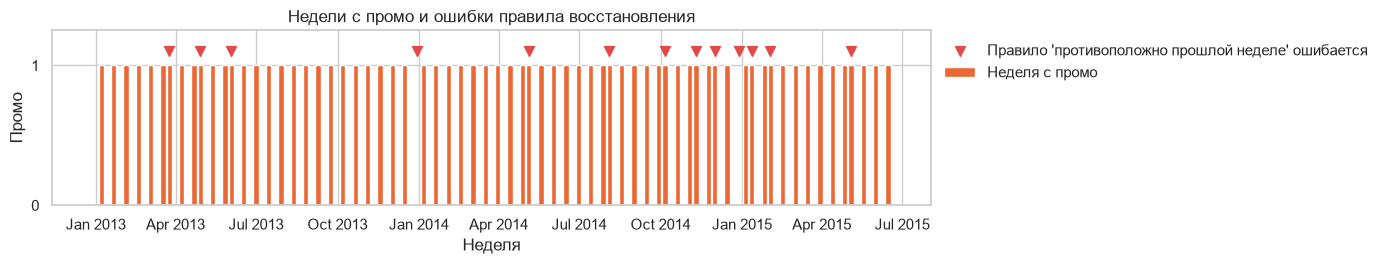

In [39]:
weekly_promo = promo_share.groupby(promo_share.index.to_period("W")).max().round()
rules = {"как две недели назад": weekly_promo.shift(2),
         "противоположно прошлой неделе": 1 - weekly_promo.shift(1)}
for name, guess in rules.items():
    valid = guess.notna()
    print(f"Правило '{name}': верно в {(guess[valid] == weekly_promo[valid]).mean():.0%} недель")

fig, ax = plt.subplots(figsize=(14, 2.8))
best_rule = "противоположно прошлой неделе"
guess = rules[best_rule]
week_start = weekly_promo.index.to_timestamp()
ax.bar(week_start, weekly_promo, width=6, color="#eb6834", label="Неделя с промо")
wrong = guess.notna() & (guess != weekly_promo)
ax.scatter(week_start[wrong.to_numpy()], np.full(wrong.sum(), 1.1), marker="v", color="#e34948", s=50,
           label=f"Правило '{best_rule}' ошибается")
ax.set(title="Недели с промо и ошибки правила восстановления", xlabel="Неделя", ylabel="Промо", ylim=(0, 1.25))
ax.set_yticks([0, 1])
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 4, 7, 10)))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0), frameon=False)
plt.tight_layout()
plt.show()

Расписание промоакций почти полностью восстанавливается по прошлому: правило "противоположно прошлой неделе" верно в 90% недель, "как две недели назад" - в 80%. Ошибки приходятся на моменты, когда промоакция идет две недели подряд или пропускается (сдвиг фазы чередования). Цена ошибки заметная: в одной неделе из десяти правило даст неверный признак промоакции, а промоакция меняет поток примерно на 20% (раздел 3.2).

**Для модели:** в реальном бизнесе расписание промоакций - это план, известный заранее, поэтому правильный вариант - передавать его на вход прогноза. Восстановление по правилу - запасной вариант, если плана нет.

### 8.2 Насколько полезно знать о промоакции

Проверяем, помогает ли информация о промоакции точнее определить обычный уровень спроса. Для этого сравниваем два варианта.

В первом случае обычный уровень определяется отдельно для каждого магазина и дня недели. Во втором дополнительно учитывается, была ли в этот день промоакция. Если после добавления информации о промоакции отклонения от обычного уровня становятся меньше, значит, этот признак действительно объясняет часть различий в спросе.

Сравнение проводим только для будних дней без государственных праздников, чтобы другие календарные эффекты меньше влияли на результат.

Это не оценка качества модели, а простая проверка того, сколько дополнительной информации о спросе дает признак Promo.

In [40]:
weekdays_only = regular_days[regular_days["DayOfWeek"].le(5)].copy()
dev_without = (weekdays_only["index"] - weekdays_only.groupby(["Store", "DayOfWeek"])["index"].transform("mean")).abs()
dev_with = (weekdays_only["index"] - weekdays_only.groupby(["Store", "DayOfWeek", "Promo"])["index"].transform("mean")).abs()
promo_value = (pd.DataFrame({"без промоакции": dev_without, "с промоакцией": dev_with, "segment": weekdays_only["segment"]})
               .groupby("segment").mean())
promo_value.loc["все магазины"] = [dev_without.mean(), dev_with.mean()]
promo_value["снижение отклонения"] = 1 - promo_value["с промоакцией"] / promo_value["без промоакции"]
promo_value.round(3)

,без промоакции,с промоакцией,снижение отклонения
segment,,,
high_check,0.128,0.093,0.272
high_traffic,0.113,0.096,0.152
mid,0.130,0.090,0.305
все магазины,0.127,0.092,0.278


Знание о промоакции уменьшает среднее отклонение индекса от "обычного" значения магазина в этот день недели на 28% (с 0.127 до 0.092 медианы магазина): в `mid` - на 31%, в `high_check` - на 27%, в `high_traffic` - на 15%. Это грубая мера, а не оценка модели, но она показывает, что промоакция - один из главных источников колебаний от недели к неделе.

**Для модели:** отказ от признака промо заметно ухудшил бы прогноз, поэтому признак промоакции включаем, а его значения на 7 дней вперед берем из плана (раздел 8.1).

### 8.3 Перезапуски Promo2

У магазинов, участвующих в Promo2, акция проводится по определенному графику, который задается в `PromoInterval`. Например, для одного магазина перезапуск может происходить в январе, апреле, июле и октябре.

В разделе 4.4 мы проверяли только изменение спроса после первого подключения магазина к Promo2. Здесь проверяем другой вопрос: "увеличивается ли поток покупателей в месяцы, когда у магазина начинается новый цикл промоакции?"

Чтобы не спутать эффект промоакции с обычной сезонностью, сравниваем магазины в пределах одного и того же календарного месяца. Например, в апреле сравниваем магазины, у которых в апреле начинается новый цикл Promo2, с магазинами, у которых в апреле перезапуска нет.

В анализ включаем только те месяцы, которые наступили после подключения магазина к Promo2. Это позволяет не смешивать эффект регулярных перезапусков с эффектом самого подключения к программе.

In [41]:
MONTHS = {"Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4, "May": 5, "Jun": 6, "Jul": 7, "Aug": 8,
          "Sept": 9, "Oct": 10, "Nov": 11, "Dec": 12}
wave_months = (store_subset.dropna(subset=["PromoInterval"]).set_index("Store")["PromoInterval"]
               .map(lambda text: {MONTHS[m] for m in text.split(",")}))
print("Графики перезапусков в выборке:", store_subset["PromoInterval"].value_counts().to_dict())

participants = regular_days[regular_days["Store"].isin(wave_months.index)].copy()
participants = participants[participants["Date"] >= participants["Store"].map(promo2_date)]
participants["month"] = participants["Date"].dt.month
wave_table = (wave_months.explode().rename("month").reset_index()
              .astype({"Store": participants["Store"].dtype, "month": int}).assign(in_wave=True))
participants = (participants.merge(wave_table, on=["Store", "month"], how="left")
                .fillna({"in_wave": False}).astype({"in_wave": bool}))
store_month = (participants.assign(period=participants["Date"].dt.to_period("M"))
               .groupby(["Store", "period", "month", "in_wave"])["index"].mean().reset_index())
by_month = store_month.groupby(["month", "in_wave"])["index"].mean().unstack()
by_month["разница"] = by_month[True] - by_month[False]
display(by_month.round(3))
print(f"Средняя разница индекса в месяцы перезапуска и в те же месяцы без перезапуска: "
      f"{by_month['разница'].mean():+.3f} (по {by_month['разница'].notna().sum()} месяцам); "
      f"магазинов-участников: {participants['Store'].nunique()}")

Графики перезапусков в выборке: {'Jan,Apr,Jul,Oct': 16, 'Feb,May,Aug,Nov': 5, 'Mar,Jun,Sept,Dec': 3}


in_wave,False,True,разница
month,,,
1,0.961,0.984,0.023
2,0.973,0.989,0.016
3,1.033,0.979,-0.054
4,1.023,1.035,0.012
5,1.022,1.048,0.027
6,1.029,0.987,-0.042
7,0.994,1.019,0.025
8,0.961,0.951,-0.010
9,0.989,0.954,-0.035


Средняя разница индекса в месяцы перезапуска и в те же месяцы без перезапуска: -0.007 (по 12 месяцам); магазинов-участников: 24


Выраженного эффекта перезапусков `Promo2` не обнаружено. В месяцы перезапуска индекс спроса у участников в среднем даже немного ниже, чем у участников с другим графиком в том же месяце: разница составляет -0,007. При этом результаты сильно различаются между месяцами: разница находится в диапазоне от -0,06 до +0,03 и не имеет устойчивого направления.

Результат нужно интерпретировать с учетом небольшого размера выборки. В анализе участвуют 24 магазина, причем графики перезапусков распределены неравномерно: 16 магазинов используют график `Jan,Apr,Jul,Oct`, 5 и 3 магазина - два других графика. Поэтому сравнения внутри отдельных месяцев основаны на небольшом количестве магазинов.

**Для модели:** по этим данным отдельный признак "месяц перезапуска `Promo2`" не выглядит полезным. Вместе с результатом раздела 4.4 это указывает на то, что `Promo2` имеет низкий приоритет среди потенциальных признаков модели.

### 8.4 Итог: какие признаки доступны на 7 дней вперед

* **Календарь** (`день недели`, `месяц`, `дни до Пасхи` и `дни до Рождества`) рассчитывается из даты, поэтому эти признаки известны заранее.

* **Государственные праздники** берутся из официального календаря и также известны заранее. Признак `StateHoliday` почти полностью заполнен (раздел 6.4). Карнавал в него не входит, поэтому его даты при необходимости можно добавить отдельно.

* **Расписание работы** (`Open`, включая закрытия на ремонт) известно заранее как план работы магазина. Для ресторана это соответствовало бы его графику работы. Если магазин по расписанию закрыт, прогнозируем 0 покупателей без использования модели.

* **Промоакции** (`Promo`) являются частью плана сети и передаются модели на вход. Если информация о промоакции недоступна, можно использовать запасное правило: считать, что в текущую неделю наличие/отсутствие промоакции противоположно прошлой. В исторических данных это правило совпадает с фактическим значением примерно в 90% недель.

* **`Promo2`** известно из характеристик магазина, однако заметного влияния на спрос по проведенному анализу не обнаружено (разделы 4.4 и 8.3).

* **Школьные каникулы** (`SchoolHoliday`) определяются региональным календарем и также известны заранее, поэтому их можно передать модели.

* **Лаги и скользящие статистики** рассчитываются только по уже известной истории. Для прогноза на несколько дней вперед нельзя использовать значения, которые станут известны только после даты прогноза. Например, при прогнозе на день `t + h` доступны только лаги, относящиеся к датам до `t`.

**Для `predict.py`** это означает, что для прогноза на следующие 7 дней нужны не только история и дата, но и известный заранее план на эти дни: расписание работы, промоакции, праздники и школьные каникулы. В данных Rossmann эти признаки есть и для отложенного периода, поэтому такой прогноз можно построить без утечки: план на будущие дни известен, а количество покупателей (`Customers`) для этих дней модели не передается.

## Итоговые выводы ноутбука

**Данные и пропуски.** Выборка из 40 магазинов содержит все три вида пропусков: регулярные закрытия (воскресенья и праздники), пробел выгрузки второго полугодия 2014 года у 9 магазинов и периоды, когда точки нет (ремонты и магазины, появившиеся позже). Аномальные дни "открыт, но 0 покупателей" оказались последним днем длинного закрытия. Ноль ставится только в регулярно закрытые дни, во всех остальных случаях, когда спрос неизвестен, - пропуск. После длинного закрытия первая неделя дает всплеск, а сам ремонт может перевести магазин на другой уровень.

**Целевая переменная.** Магазины сильно различаются по масштабу: их медианный поток покупателей отличается почти в 5 раз. После нормализации относительно обычного уровня конкретного магазина распределение становится значительно компактнее. Сезонные изменения в основном выражаются как относительные изменения уровня спроса, поэтому для модели важно учитывать индивидуальный масштаб магазина. Выручка тесно связана с количеством покупателей и в основном используется как описательная характеристика; ее лаги можно дополнительно проверить как потенциальные признаки.

**Недельный цикл и промо.** Промоакции являются общим календарным фактором для сети и проводятся с понедельника по пятницу. Недели с промоакцией и без промоакции в основном чередуются, а наличие промоакции связано с повышением потока примерно на 20%. Из-за этой структуры лаги 14 и 28 дней лучше соответствуют той же фазе промоакции, чем лаги 7 и 21 дней. При этом недельный профиль отличается между сегментами и отдельными магазинами, поэтому одного общего профиля для всех магазинов недостаточно.

**Динамика.** Общего выраженного тренда по сети не обнаружено. При этом отдельные магазины могут постепенно расти или снижаться, а также иметь временные изменения уровня спроса. Поэтому для прогноза на неделю вперед важнее текущий уровень конкретного магазина и его недавняя история, чем общий признак времени.

**Годовая сезонность и праздники.** Годовая сезонность повторяется из года в год, если учитывать влияние промоакций и плавающих праздников. Наиболее заметные изменения связаны с декабрем и Пасхой. Праздники влияют на данные не только через закрытие магазинов: часть спроса переносится на соседние дни. Рождественский период является наиболее необычным периодом, но при этом хорошо описывается календарными признаками.

**Выбросы.** Выбросами являются 2,8% открытых дней. Большинство из них (78%) связано с известными календарными или бизнес-событиями, поэтому удалять такие наблюдения не следует. Их лучше учитывать с помощью соответствующих признаков. Среди оставшихся выбросов встречаются массовые разовые снижения спроса и повторяющиеся повышения в конце месяца.

**Решения для признаков и модели:**

* целевую переменную можно задавать относительно недавнего уровня конкретного магазина или в логарифмическом масштабе; индивидуальный уровень магазина учитывать через скользящие средние по недавней истории, без отдельного общего признака времени;
* использовать лаги 14 и 28 дней как значения того же дня недели и той же фазы промоакции; лаг 7 дней использовать вместе с признаком `Promo`, а лаг 364 дня рассматривать как дополнительный признак;
* добавить `Promo` из известного плана, день недели, месяц, сегмент магазина и признаки близости к праздникам с учетом их типа, а также отдельные признаки для Пасхи, рождественского периода и карнавала;
* учитывать число дней с момента открытия после длинного закрытия;
* не рассчитывать лаги и скользящие статистики через периоды отсутствия магазина или пробелы в выгрузке;
* отдельно проверить на этапе моделирования признаки дня месяца, школьных каникул, открытия конкурента и `Promo2`.

**Решения для валидации и метрик:**

* дни, когда магазин закрыт по известному расписанию, прогнозировать как 0 по отдельному правилу и не включать в расчет метрик;
* в отложенном периоде нет государственных праздников, поэтому качество на праздничных днях дополнительно проверять на временной скользящей валидации внутри тренировочной выборки;
* оценивать качество как по всей выборке, так и отдельно по группам магазинов и проблемным случаям; при сравнении MAE учитывать разный масштаб магазинов;
* в качестве основного наивного бейзлайна использовать значение того же дня недели неделю назад, но дополнительно показать сезонный бейзлайн со сдвигом на 14 дней, который сохраняет ту же фазу промоакции.